In [7]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random
import torch
import re

In [8]:
seed = 42

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
set_seed(seed)

In [5]:
initial_df = pd.read_csv("../Initial_Process/nlst_780_prsn_idc_20210527.csv")

In [6]:
initial_df.head()

,race,cigsmok,gender,age,loclhil,locllow,loclup,locrhil,locrlow,locrmid,...,can_scr,canc_rpt_link,pid,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed
0,1,1,1,70,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100001,2011.02.03/05.12.21,0.0,511.0,NaN,NaN,2353,NaN
1,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100002,2011.02.03/05.12.21,13.0,349.0,731.0,NaN,2391,NaN
2,1,1,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100003,2011.02.03/05.12.21,12.0,374.0,738.0,NaN,2381,NaN
3,1,0,1,60,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100004,2011.02.03/05.12.21,8.0,452.0,743.0,NaN,2688,NaN
4,1,0,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100005,2011.02.03/05.12.21,56.0,382.0,746.0,NaN,2435,NaN


In [70]:
initial_df

,race,cigsmok,gender,age,loclhil,locllow,loclup,locrhil,locrlow,locrmid,...,can_scr,canc_rpt_link,pid,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed
0,1,1,1,70,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100001,2011.02.03/05.12.21,0.0,511.0,NaN,NaN,2353,NaN
1,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100002,2011.02.03/05.12.21,13.0,349.0,731.0,NaN,2391,NaN
2,1,1,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100003,2011.02.03/05.12.21,12.0,374.0,738.0,NaN,2381,NaN
3,1,0,1,60,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100004,2011.02.03/05.12.21,8.0,452.0,743.0,NaN,2688,NaN
4,1,0,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100005,2011.02.03/05.12.21,56.0,382.0,746.0,NaN,2435,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53447,1,1,2,73,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218890,2011.02.03/05.12.21,0.0,362.0,727.0,NaN,2245,NaN
53448,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218891,2011.02.03/05.12.21,0.0,395.0,NaN,NaN,2380,NaN
53449,1,0,1,56,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218892,2011.02.03/05.12.21,0.0,431.0,708.0,NaN,2577,NaN
53450,1,0,1,69,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218893,2011.02.03/05.12.21,0.0,378.0,756.0,NaN,2305,NaN


In [71]:
initial_df.describe()

,race,cigsmok,gender,age,loclhil,locllow,loclup,locrhil,locrlow,locrmid,...,cancyr,can_scr,canc_rpt_link,pid,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed
count,53452.000000,53452.000000,53452.000000,53452.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,...,2058.000000,53452.000000,53452.000000,53452.000000,52361.000000,48812.000000,47456.000000,2058.000000,53452.000000,2021.000000
mean,1.651500,0.481928,1.410125,61.417926,0.035471,0.133625,0.234208,0.049563,0.160836,0.067055,...,2.397473,0.093617,0.018128,149787.261861,15.140658,390.233406,757.411939,1046.368319,2280.369228,257.662543
std,6.672672,0.499678,0.491861,5.023972,0.185013,0.340332,0.423606,0.217092,0.367469,0.250179,...,1.970229,0.543578,0.133417,44861.527538,25.734827,49.372804,60.264587,743.300512,526.608210,140.858316
min,1.000000,0.000000,1.000000,43.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,100001.000000,-4.000000,116.000000,575.000000,0.000000,0.000000,110.000000
25%,1.000000,0.000000,1.000000,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,113368.750000,0.000000,359.000000,720.000000,398.000000,2251.000000,110.000000
50%,1.000000,0.000000,1.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,126738.500000,2.000000,378.000000,739.000000,927.000000,2420.000000,310.000000
75%,1.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.000000,0.000000,205492.250000,22.000000,406.000000,772.000000,1721.750000,2549.000000,400.000000
max,99.000000,1.000000,2.000000,79.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,7.000000,4.000000,1.000000,218894.000000,334.000000,755.000000,1502.000000,2618.000000,2983.000000,999.000000


In [63]:
initial_df.iloc[:4]

,race,cigsmok,gender,age,loclhil,locllow,loclup,locrhil,locrlow,locrmid,...,can_scr,canc_rpt_link,pid,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed
0,1,1,1,70,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100001,2011.02.03/05.12.21,0.0,511.0,NaN,NaN,2353,NaN
1,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100002,2011.02.03/05.12.21,13.0,349.0,731.0,NaN,2391,NaN
2,1,1,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100003,2011.02.03/05.12.21,12.0,374.0,738.0,NaN,2381,NaN
3,1,0,1,60,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100004,2011.02.03/05.12.21,8.0,452.0,743.0,NaN,2688,NaN


In [47]:
len(initial_df['pid'].unique())

53452

In [48]:
initial_df.columns

Index(['race', 'cigsmok', 'gender', 'age', 'loclhil', 'locllow', 'loclup',
       'locrhil', 'locrlow', 'locrmid', 'locunk', 'locrup', 'locoth', 'locmed',
       'loclmsb', 'locrmsb', 'loccar', 'loclin', 'lesionsize', 'de_type',
       'de_grade', 'de_stag', 'scr_res0', 'scr_res1', 'scr_res2', 'scr_iso0',
       'scr_iso1', 'scr_iso2', 'cancyr', 'can_scr', 'canc_rpt_link', 'pid',
       'dataset_version', 'scr_days0', 'scr_days1', 'scr_days2', 'candx_days',
       'canc_free_days', 'de_stag_7thed'],
      dtype='object')

In [49]:
len(initial_df.columns)

39

# IDC: Participant Data Dictionary

**Date Created:** 05/28/2021  
**Sections:** 5  
**Entries:** 33  

---

## Table of Contents

| Section Number | Section Title |
| --- | --- |
| 1 | Study |
| 2 | Demographic |
| 3 | Smoking |
| 4 | Screening |
| 6 | Lung Cancer |

---

## Section 1: Study

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| dataset_version | Date Stamp for Datasets |  | Char, 23 |
| pid | Participant Identifier | A unique identifier given to each participant. For LSS participants, pid has a format of 1xx,xxx, while for ACRIN participants, pid has a format of 2xx,xxx. | Numeric |

---

## Section 2: Demographic

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| age | Age at randomization (in years; whole number) |  | Numeric |
| gender | Gender |  | 1 = "Male"<br>2 = "Female" |
| race | Race |  | 1 = "White"<br>2 = "Black or African-American"<br>3 = "Asian"<br>4 = "American Indian or Alaskan Native"<br>5 = "Native Hawaiian or Other Pacific Islander"<br>6 = "More than one race"<br>7 = "Participant refused to answer"<br>95 = "Missing data form - form is not expected to ever be completed"<br>96 = "Missing - no response"<br>98 = "Missing - form was submitted and the answer was left blank"<br>99 = "Unknown / decline to answer" |

---

## Section 3: Smoking

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| cigsmok | Smoking status at T0 | Cigarette smoking status (current vs former) at randomization. Former smokers must have quit within 15 years of eligibility determination to have been eligible for the trial. | 0 = "Former"<br>1 = "Current" |

---

## Section 4: Screening

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| scr_days0-2 | Days since randomization at time of screening (for T0, T1, and T2 exams) | Days from randomization to the date of the screening exam.<br><br>Contains information on either the spiral CT or the chest x-ray screening exam, depending on which study arm the participant was randomized to (see rndgroup). | Numeric<br>.E = "Screen date after lung cancer diagnosis"<br>.N = "No screen date on record"<br>.W = "Wrong Screen Administered" |
| scr_iso0-2 | Result of isolation screen (for T0, T1, and T2 exams) | Isolation read of the image(s) before comparing with prior images. Contains information on either spiral CT or chest x-ray. | 1 = "Negative screen, no significant abnormalities"<br>2 = "Negative screen, minor abnormalities not suspicious for lung cancer"<br>3 = "Negative screen, significant abnormalities not suspicious for lung cancer"<br>4 = "Positive, Change Unspecified, nodule(s) >= 4 mm or enlarging nodule(s), mass(es), other non-specific abnormalities suspicious for lung cancer"<br>10 = "Inadequate Image"<br>11 = "Not Compliant - Left Study"<br>13 = "Not Expected - Cancer before screening window"<br>14 = "Not Expected - Death before screening window"<br>15 = "Not Compliant - Refused a screen"<br>17 = "Not Compliant - Wrong Screen"<br>23 = "Not Expected - Cancer in screening window"<br>24 = "Not Expected - Death in screening window"<br>95 = "Not Compliant - Erroneous Report of Lung Cancer Before Screen (LSS Only)"<br>97 = "Not Compliant - Form Not Submitted, Window Closed" |
| scr_res0-2 | Results of screening (for T0, T1, and T2 exams) | Official result of screening after comparing current and prior images.<br>Positive screens (4, 5, or 6) advised diagnostic evaluation. | 1 = "Negative screen, no significant abnormalities"<br>2 = "Negative screen, minor abnormalities not suspicious for lung cancer"<br>3 = "Negative screen, significant abnormalities not suspicious for lung cancer"<br>4 = "Positive, Change Unspecified, nodule(s) >= 4 mm or enlarging nodule(s), mass(es), other non-specific abnormalities suspicious for lung cancer"<br>5 = "Positive, No Significant Change, stable abnormalities potentially related to lung cancer, no significant change since prior screening exam."<br>6 = "Positive, other"<br>10 = "Inadequate Image"<br>11 = "Not Compliant - Left Study"<br>13 = "Not Expected - Cancer before screening window"<br>14 = "Not Expected - Death before screening window"<br>15 = "Not Compliant - Refused a screen"<br>17 = "Not Compliant - Wrong Screen"<br>23 = "Not Expected - Cancer in screening window"<br>24 = "Not Expected - Death in screening window"<br>95 = "Not Compliant - Erroneous Report of Lung Cancer Before Screen (LSS Only)"<br>97 = "Not Compliant - Form Not Submitted, Window Closed" |

---

## Section 6: Lung Cancer

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| can_scr | Result of screen associated with first confirmed lung cancer diagnosis |  | 0 = "No Cancer"<br>1 = "Positive Screen"<br>2 = "Negative Screen"<br>3 = "Missed Screen"<br>4 = "Post Screening" |
| canc_free_days | Days from randomization to last known lung cancer-free date | Do not use for incidence rate calculations. | Numeric |
| canc_rpt_link | Diagnosis associated with positive screen? |  | 0 = "No"<br>1 = "Yes" |
| cancyr | Study year of first confirmed lung cancer |  | .N = "Not Applicable"<br>0 = "T0"<br>1 = "T1"<br>2 = "T2"<br>3 = "T3"<br>4 = "T4"<br>5 = "T5"<br>6 = "T6"<br>7 = "T7" |
| candx_days | Days from randomization to first lung cancer diagnosis |  | Numeric<br>.N = "No diagnosis date on record" |
| de_grade | Lung cancer grade |  | .N = "Not Applicable"<br>1 = "Grade Cannot Be Assessed (GX)"<br>2 = "Well Differentiated (G1)"<br>3 = "Moderately Differentiated (G2)"<br>4 = "Poorly Differentiated (G3)"<br>5 = "Undifferentiated (G4)"<br>6 = "Unspecified in Pathology Report"<br>8 = "Unknown"<br>9 = "Missing" |
| de_stag | Lung cancer Stage (AJCC 6) | Combines clinical & pathologic staging. | .M = "Missing"<br>.N = "Not Applicable"<br>110 = "Stage IA"<br>120 = "Stage IB"<br>210 = "Stage IIA"<br>220 = "Stage IIB"<br>310 = "Stage IIIA"<br>320 = "Stage IIIB"<br>400 = "Stage IV"<br>888 = "TNM not available"<br>900 = "Occult Carcinoma"<br>994 = "Carcinoid, cannot be assessed"<br>999 = "Unknown, cannot be assessed" |
| de_stag_7thed | AJCC 7th edition stage | Stage of first primary lung cancer, based on AJCC 7th edition stage. | .M = "Missing"<br>.N = "Not Applicable"<br>110 = "Stage IA"<br>120 = "Stage IB"<br>210 = "Stage IIA"<br>220 = "Stage IIB"<br>310 = "Stage IIIA"<br>320 = "Stage IIIB"<br>400 = "Stage IV"<br>900 = "Occult Carcinoma"<br>999 = "Unknown, cannot be assessed" |
| de_type | Lung cancer type from ICD-O-3 morphology | For LSS participants, recorded separately from full ICD code. | Numeric<br>.M = "Missing"<br>.N = "Not Applicable" |
| lesionsize | Tumor lesion size (mm) |  | Numeric<br>.M = "Missing"<br>.N = "Not Applicable" |
| loccar | Cancer in Carina |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| loclhil | Cancer in Left Hilum |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| loclin | Cancer in Lingula |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locllow | Cancer in Left lower lobe |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| loclmsb | Cancer in Left main stem bronchus |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| loclup | Cancer in Left upper lobe |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locmed | Cancer in Mediastinum |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locoth | Cancer in Other Location |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locrhil | Cancer in Right Hilum |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locrlow | Cancer in Right lower lobe |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locrmid | Cancer in Right middle lobe |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locrmsb | Cancer in Right main stem bronchus |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locrup | Cancer in Right upper lobe |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |
| locunk | Cancer in Unknown location |  | .N = "Not Applicable"<br>0 = "No"<br>1 = "Yes" |


In [50]:
len(initial_df)

53452

In [51]:
initial_missing_data = initial_df.isna().sum()
initial_missing_data

race                   0
cigsmok                0
gender                 0
age                    0
loclhil            51394
locllow            51394
loclup             51394
locrhil            51394
locrlow            51394
locrmid            51394
locunk             51394
locrup             51394
locoth             51394
locmed             51394
loclmsb            51394
locrmsb            51394
loccar             51394
loclin             51394
lesionsize         51662
de_type            51418
de_grade           51394
de_stag            51395
scr_res0               0
scr_res1               0
scr_res2               0
scr_iso0               0
scr_iso1               0
scr_iso2               0
cancyr             51394
can_scr                0
canc_rpt_link          0
pid                    0
dataset_version        0
scr_days0           1091
scr_days1           4640
scr_days2           5996
candx_days         51394
canc_free_days         0
de_stag_7thed      51431
dtype: int64

In [21]:
initial_missing_data.values

array([    0,     0,     0,     0, 51394, 51394, 51394, 51394, 51394,
       51394, 51394, 51394, 51394, 51394, 51394, 51394, 51394, 51394,
       51662, 51418, 51394, 51395,     0,     0,     0,     0,     0,
           0, 51394,     0,     0,     0,     0,  1091,  4640,  5996,
       51394,     0, 51431], dtype=int64)

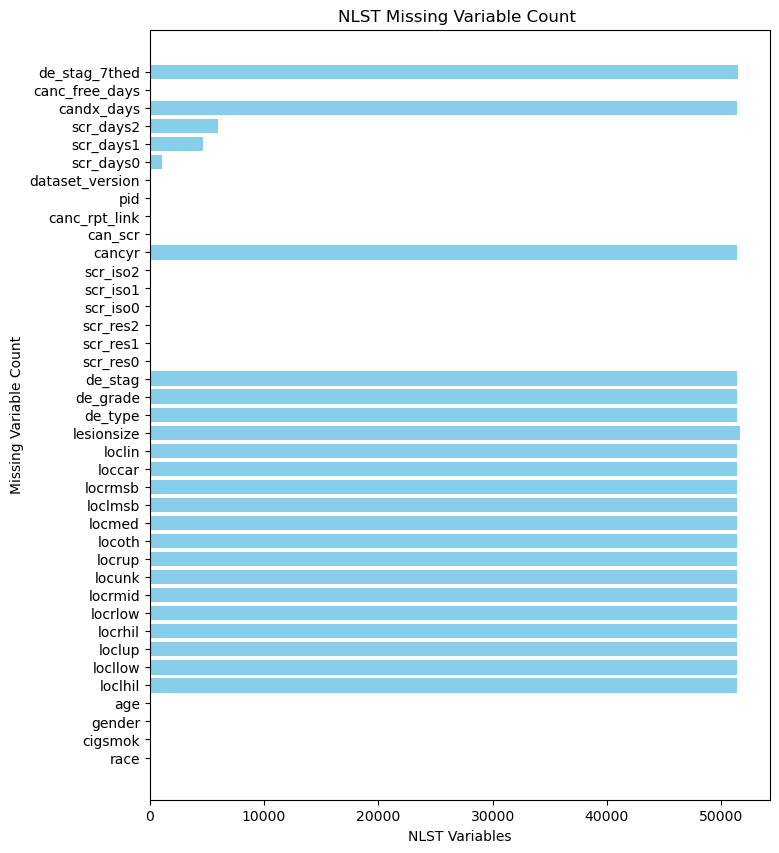

In [22]:
plt.figure(figsize=(8,10))
plt.barh(initial_missing_data.keys(), initial_missing_data.values, color='skyblue')

# Add labels and title
plt.xlabel('NLST Variables')
plt.ylabel('Missing Variable Count')
plt.title('NLST Missing Variable Count ')

# Show the plot
plt.show()

In [23]:
initial_df_numeric_EDA = initial_df[['race', 'cigsmok', 'gender', 'age']]
initial_df_numeric_EDA.describe()

,race,cigsmok,gender,age
count,53452.000000,53452.000000,53452.000000,53452.000000
mean,1.651500,0.481928,1.410125,61.417926
std,6.672672,0.499678,0.491861,5.023972
min,1.000000,0.000000,1.000000,43.000000
25%,1.000000,0.000000,1.000000,57.000000
50%,1.000000,0.000000,1.000000,60.000000
75%,1.000000,1.000000,2.000000,65.000000
max,99.000000,1.000000,2.000000,79.000000


In [24]:
gender_counts = initial_df.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(initial_df)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

Distribution of patients by race:


,gender,# count,percentage
0,1,31530,58.9875%
1,2,21922,41.0125%


In [25]:
smoke_count = initial_df.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(initial_df)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

Distribution of patients by race:


,cigsmok,# count,percentage
0,0,27692,51.8072%
1,1,25760,48.1928%


| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| race | Race |  | 1 = "White"<br>2 = "Black or African-American"<br>3 = "Asian"<br>4 = "American Indian or Alaskan Native"<br>5 = "Native Hawaiian or Other Pacific Islander"<br>6 = "More than one race"<br>7 = "Participant refused to answer"<br>95 = "Missing data form - form is not expected to ever be completed"<br>96 = "Missing - no response"<br>98 = "Missing - form was submitted and the answer was left blank"<br>99 = "Unknown / decline to answer" |


In [26]:
race_counts = initial_df.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(initial_df)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


Distribution of patients by race:


,race,# count,percentage
0,1,48549,90.8273%
1,2,2376,4.4451%
2,3,1095,2.0486%
3,4,190,0.3555%
4,5,193,0.3611%
5,6,679,1.2703%
6,7,109,0.2039%
7,95,175,0.3274%
8,96,3,0.0056%
9,98,2,0.0037%


In [27]:
90.8273+4.4451+2.0486+0.3555+0.3611+1.2703+0.2039+0.3274+0.0056+0.0037+0.1515


99.99999999999999

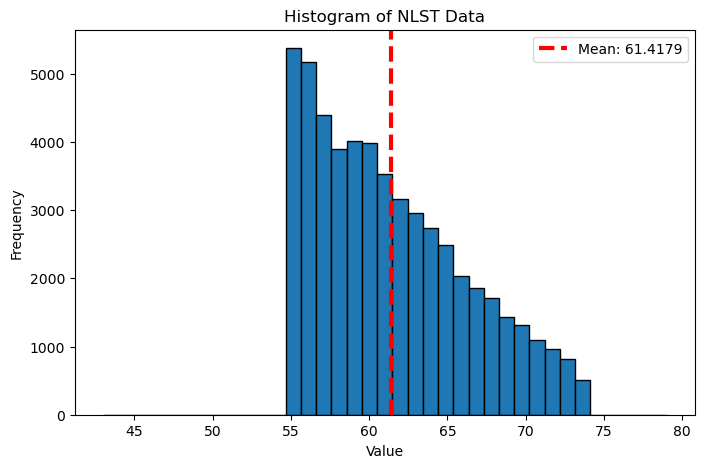

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(initial_df['age'], bins=37, edgecolor='black')

plt.title('Histogram of NLST Data')
plt.xlabel('Value')
plt.ylabel('Frequency')


plt.axvline(
    initial_df['age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=3,
    label=f'Mean: {initial_df['age'].mean():.4f}'
)
plt.legend()
plt.show()

In [29]:
print(f"{initial_df.columns} Length: {len(initial_df.columns)}")

Index(['race', 'cigsmok', 'gender', 'age', 'loclhil', 'locllow', 'loclup',
       'locrhil', 'locrlow', 'locrmid', 'locunk', 'locrup', 'locoth', 'locmed',
       'loclmsb', 'locrmsb', 'loccar', 'loclin', 'lesionsize', 'de_type',
       'de_grade', 'de_stag', 'scr_res0', 'scr_res1', 'scr_res2', 'scr_iso0',
       'scr_iso1', 'scr_iso2', 'cancyr', 'can_scr', 'canc_rpt_link', 'pid',
       'dataset_version', 'scr_days0', 'scr_days1', 'scr_days2', 'candx_days',
       'canc_free_days', 'de_stag_7thed'],
      dtype='object') Length: 39


In [30]:
initial_df_transform = initial_df.copy()

In [31]:
initial_df_transform.loc[:,"cancyr"] = initial_df["cancyr"].fillna(99)

In [32]:
new_race_column = []
for item in initial_df['race']:
    if item not in [1,2,3,4,5,6]:
        new_race_column.append(99)
    else:
        new_race_column.append(item)

In [33]:
initial_df_transform.loc[:,"race"] = new_race_column

| Variable         | Description                                                                                       | Format/Values                                                                 |
|------------------|---------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------|
| `can_scr`        | Result of screen associated with the first confirmed lung cancer diagnosis                        | `0="No Cancer"`, `1="Positive Screen"`, `2="Negative Screen"`, `3="Missed Screen"`, `4="Post Screening"` |                                                                    |
| `canc_rpt_link`  | Is the diagnosis of lung cancer associated with a positive screen?                                | `0="No"`, `1="Yes"`                                                           |
| `cancyr`         | Study year associated with first confirmed lung cancer                                            | `99="Not Applicable"`, `0="T0"`, `1="T1"`, `2="T2"`, `3="T3"`, `4="T4"`, `5="T5"`, `6="T6"`, `7="T7"` |

In [34]:
initial_df_transform['cancyr']

0        99.0
1        99.0
2        99.0
3        99.0
4        99.0
         ... 
53447    99.0
53448    99.0
53449    99.0
53450    99.0
53451    99.0
Name: cancyr, Length: 53452, dtype: float64

In [35]:
random_seed_picked = 42
random_seed_picked

42

In [36]:
initial_df_transform['race'].value_counts()

race
1     48549
2      2376
3      1095
6       679
99      370
5       193
4       190
Name: count, dtype: int64

In [37]:
initial_df

,race,cigsmok,gender,age,loclhil,locllow,loclup,locrhil,locrlow,locrmid,...,can_scr,canc_rpt_link,pid,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed
0,1,1,1,70,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100001,2011.02.03/05.12.21,0.0,511.0,NaN,NaN,2353,NaN
1,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100002,2011.02.03/05.12.21,13.0,349.0,731.0,NaN,2391,NaN
2,1,1,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100003,2011.02.03/05.12.21,12.0,374.0,738.0,NaN,2381,NaN
3,1,0,1,60,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100004,2011.02.03/05.12.21,8.0,452.0,743.0,NaN,2688,NaN
4,1,0,1,64,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,100005,2011.02.03/05.12.21,56.0,382.0,746.0,NaN,2435,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53447,1,1,2,73,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218890,2011.02.03/05.12.21,0.0,362.0,727.0,NaN,2245,NaN
53448,1,1,1,66,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218891,2011.02.03/05.12.21,0.0,395.0,NaN,NaN,2380,NaN
53449,1,0,1,56,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218892,2011.02.03/05.12.21,0.0,431.0,708.0,NaN,2577,NaN
53450,1,0,1,69,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,218893,2011.02.03/05.12.21,0.0,378.0,756.0,NaN,2305,NaN


## NLST-Seg Dataset

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
| ID | Participant Identifier | A unique identifier given to each participant. For LSS participants, pid has a format of 1xx,xxx, while for ACRIN participants, pid has a format of 2xx,xxx. | Numeric |
| cigsmok | Smoking status at T0 | Cigarette smoking status (current vs former) at randomization. Former smokers must have quit within 15 years of eligibility determination to have been eligible for the trial. | 0 = "Former"<br>1 = "Current" |
| age | Age at randomization (in years; whole number) |  | Numeric |
| gender | Gender |  | 1 = "Male"<br>2 = "Female" |
| race | Race |  | 1 = "White"<br>2 = "Black or African-American"<br>3 = "Asian"<br>4 = "American Indian or Alaskan Native"<br>5 = "Native Hawaiian or Other Pacific Islander"<br>6 = "More than one race"<br>99 = "Unknown / decline to answer" |
| Stage AJCC7th | AJCC 7th edition stage | Stage of first primary lung cancer, based on AJCC 7th edition stage. | "Stage IA"<br> "Stage IB"<br> "Stage IIA"<br> "Stage IIB"<br> "Stage IIIA"<br> "Stage IIIB"<br> "Stage IV"<br> "Occult Carcinoma"<br> "Unknown, cannot be assessed"             |

In [32]:
nii_ct_file_location = list(Path("G:/My Drive/NLST_seg").iterdir())
nii_ct_file_location

[WindowsPath('G:/My Drive/NLST_seg/2_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/3_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/4_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/5_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/6_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/7_LungTumor'),
 WindowsPath('G:/My Drive/NLST_seg/1_Table')]

In [33]:
nii_ct_file_location_dataframe = nii_ct_file_location[-1]
# for later
nii_ct_file_location_image = nii_ct_file_location[:-1]

In [34]:
table_data_NLST_seg = list(list(nii_ct_file_location_dataframe.iterdir())[0].iterdir())
table_data_NLST_seg

[WindowsPath('G:/My Drive/NLST_seg/1_Table/1_Table/Image.xlsx'),
 WindowsPath('G:/My Drive/NLST_seg/1_Table/1_Table/Label.xlsx'),
 WindowsPath('G:/My Drive/NLST_seg/1_Table/1_Table/Patient.xlsx')]

In [35]:
table_data_NLST_seg[0]

WindowsPath('G:/My Drive/NLST_seg/1_Table/1_Table/Image.xlsx')

In [36]:
NLST_seg_Patient_data = pd.read_excel(table_data_NLST_seg[2])
NLST_seg_Patient_data.head()

,Mainfolder,ID,race,cigsmok,gender,age,cancyr,Stage AJCC7th,de_typecode,de_type
0,01_LungTumor,100012,1,1,2,61,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
1,01_LungTumor,100147,1,0,1,68,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
2,01_LungTumor,100158,1,0,1,65,2,Stage IA,8140.0,"Adenocarcinoma, NOS"
3,01_LungTumor,100242,1,0,2,60,0,Stage IA,8250.0,Lepidic adenocarcinoma
4,01_LungTumor,100280,1,1,2,60,1,Stage IA,8140.0,"Adenocarcinoma, NOS"


In [37]:
NLST_seg_Patient_data_is_na = NLST_seg_Patient_data.isna().sum()

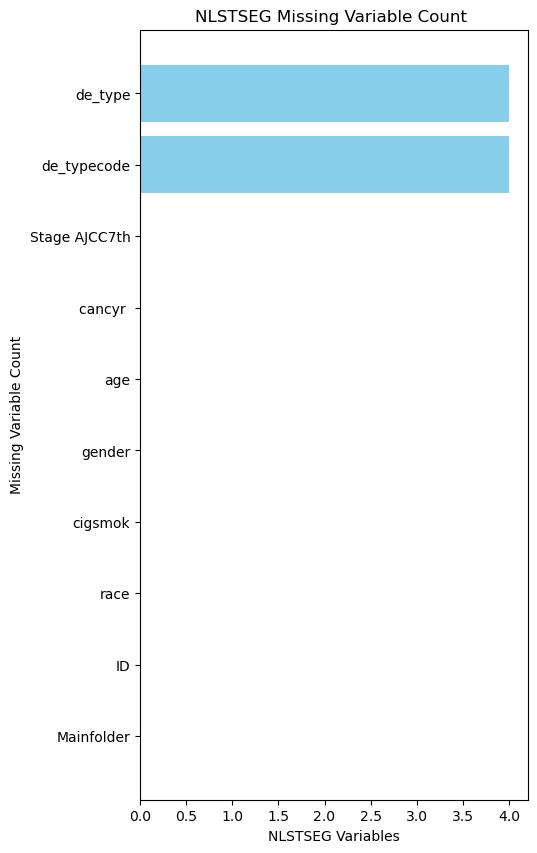

In [38]:
plt.figure(figsize=(5,10))
plt.barh(NLST_seg_Patient_data_is_na.keys(), NLST_seg_Patient_data_is_na.values, color='skyblue')

# Add labels and title
plt.xlabel('NLSTSEG Variables')
plt.ylabel('Missing Variable Count')
plt.title('NLSTSEG Missing Variable Count ')

# Show the plot
plt.show()

In [40]:
race_counts = NLST_seg_Patient_data.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(NLST_seg_Patient_data)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


Distribution of patients by race:


,race,# count,percentage
0,1,561,92.7273%
1,2,23,3.8017%
2,3,10,1.6529%
3,4,4,0.6612%
4,5,2,0.3306%
5,6,4,0.6612%
6,99,1,0.1653%


In [41]:
lung_type = NLST_seg_Patient_data.groupby('Stage AJCC7th')['age'].count().reset_index()
lung_type = lung_type.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(NLST_seg_Patient_data)

# 3. Calculate the percentage for each lung type.
lung_type['percentage'] = (lung_type['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
lung_type['percentage'] = lung_type['percentage'].map('{:.4f}%'.format)

# Display the final table with lung type, count, and percentage.
print("Distribution of patients by Lung type:")
lung_type

Distribution of patients by Lung type:


,Stage AJCC7th,# count,percentage
0,"Carcinoid, cannot be assessed",2,0.3306%
1,Stage IA,315,52.0661%
2,Stage IB,63,10.4132%
3,Stage IIA,43,7.1074%
4,Stage IIB,18,2.9752%
5,Stage IIIA,73,12.0661%
6,Stage IIIB,15,2.4793%
7,Stage IV,70,11.5702%
8,"Unknown, cannot be assessed",6,0.9917%


In [42]:
smoke_count = NLST_seg_Patient_data.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(NLST_seg_Patient_data)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

Distribution of patients by race:


,cigsmok,# count,percentage
0,0,268,44.2975%
1,1,337,55.7025%


In [43]:
gender_counts = NLST_seg_Patient_data.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(NLST_seg_Patient_data)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

Distribution of patients by race:


,gender,# count,percentage
0,1,351,58.0165%
1,2,254,41.9835%


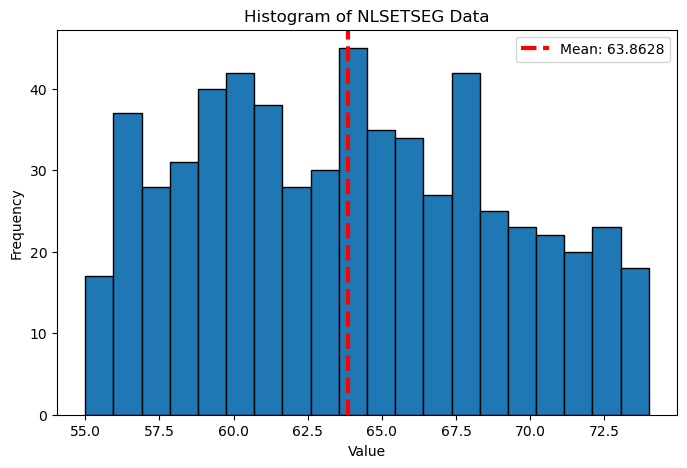

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(NLST_seg_Patient_data['age'], bins=20, edgecolor='black')

plt.title('Histogram of NLSETSEG Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.axvline(
    NLST_seg_Patient_data['age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=3,
    label=f'Mean: {NLST_seg_Patient_data['age'].mean():.4f}'
)
plt.legend()
plt.show()

In [45]:
NLST_SEG_EDA = NLST_seg_Patient_data[['race', 'cigsmok', 'gender', 'age']]
NLST_SEG_EDA.describe()

,race,cigsmok,gender,age
count,605.000000,605.000000,605.000000,605.000000
mean,1.299174,0.557025,1.419835,63.862810
std,4.024110,0.497149,0.493940,5.295508
min,1.000000,0.000000,1.000000,55.000000
25%,1.000000,0.000000,1.000000,59.000000
50%,1.000000,1.000000,1.000000,64.000000
75%,1.000000,1.000000,2.000000,68.000000
max,99.000000,1.000000,2.000000,74.000000


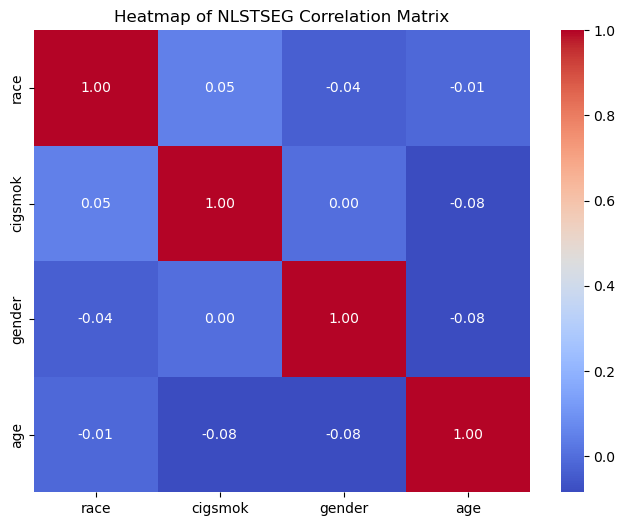

In [47]:
import seaborn as sns

import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = NLST_SEG_EDA.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Add labels and title
plt.title("Heatmap of NLSTSEG Correlation Matrix")
plt.show()

In [48]:
NLST_seg_Patient_data['race'].unique()

array([ 1,  2,  5,  3,  6,  4, 99], dtype=int64)

In [49]:
len(NLST_seg_Patient_data['Stage AJCC7th'].unique())

9

In [50]:
NLST_seg_Patient_data.columns

Index(['Mainfolder', 'ID', 'race', 'cigsmok', 'gender', 'age', 'cancyr ',
       'Stage AJCC7th', 'de_typecode', 'de_type'],
      dtype='object')

In [51]:
len(NLST_seg_Patient_data.columns)

10

In [52]:
NLST_seg_Patient_data

,Mainfolder,ID,race,cigsmok,gender,age,cancyr,Stage AJCC7th,de_typecode,de_type
0,01_LungTumor,100012,1,1,2,61,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
1,01_LungTumor,100147,1,0,1,68,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
2,01_LungTumor,100158,1,0,1,65,2,Stage IA,8140.0,"Adenocarcinoma, NOS"
3,01_LungTumor,100242,1,0,2,60,0,Stage IA,8250.0,Lepidic adenocarcinoma
4,01_LungTumor,100280,1,1,2,60,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
...,...,...,...,...,...,...,...,...,...,...
600,06_LungTumor,218307,1,1,2,72,2,Stage IIIA,8070.0,"Squamous cell carcinoma, NOS"
601,06_LungTumor,218357,2,1,1,66,2,Stage IV,8046.0,Non-small cell carcinoma
602,06_LungTumor,218368,1,0,2,74,0,Stage IV,8046.0,Non-small cell carcinoma
603,06_LungTumor,218391,1,0,1,66,1,Stage IA,8140.0,"Adenocarcinoma, NOS"


In [53]:
Positive_data = NLST_seg_Patient_data[~((NLST_seg_Patient_data["Stage AJCC7th"] == 'Carcinoid, cannot be assessed') | (NLST_seg_Patient_data["Stage AJCC7th"] == 'Unknown, cannot be assessed'))].reset_index(drop=True).copy()
Positive_data

,Mainfolder,ID,race,cigsmok,gender,age,cancyr,Stage AJCC7th,de_typecode,de_type
0,01_LungTumor,100012,1,1,2,61,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
1,01_LungTumor,100147,1,0,1,68,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
2,01_LungTumor,100158,1,0,1,65,2,Stage IA,8140.0,"Adenocarcinoma, NOS"
3,01_LungTumor,100242,1,0,2,60,0,Stage IA,8250.0,Lepidic adenocarcinoma
4,01_LungTumor,100280,1,1,2,60,1,Stage IA,8140.0,"Adenocarcinoma, NOS"
...,...,...,...,...,...,...,...,...,...,...
592,06_LungTumor,218307,1,1,2,72,2,Stage IIIA,8070.0,"Squamous cell carcinoma, NOS"
593,06_LungTumor,218357,2,1,1,66,2,Stage IV,8046.0,Non-small cell carcinoma
594,06_LungTumor,218368,1,0,2,74,0,Stage IV,8046.0,Non-small cell carcinoma
595,06_LungTumor,218391,1,0,1,66,1,Stage IA,8140.0,"Adenocarcinoma, NOS"


## NLST DATA (NO Cancer) Sample Finding


## Section 4: Screening

| Variable | Label | Description | Format Text |
| --- | --- | --- | --- |
 can_scr | Result of screen associated with first confirmed lung cancer diagnosis |  | 0 = "No Cancer"<br>1 = "Positive Screen"<br>2 = "Negative Screen"<br>3 = "Missed Screen"<br>4 = "Post Screening" |
| canc_rpt_link | Diagnosis associated with positive screen? |  | 0 = "No"<br>1 = "Yes" |
| cancyr | Study year of first confirmed lung cancer |  | .N = "Not Applicable"<br>0 = "T0"<br>1 = "T1"<br>2 = "T2"<br>3 = "T3"<br>4 = "T4"<br>5 = "T5"<br>6 = "T6"<br>7 = "T7" |
| scr_iso0-2 | Result of isolation screen (for T0, T1, and T2 exams) | Isolation read of the image(s) before comparing with prior images. Contains information on either spiral CT or chest x-ray. | 1 = "Negative screen, no significant abnormalities"<br>2 = "Negative screen, minor abnormalities not suspicious for lung cancer"<br>3 = "Negative screen, significant abnormalities not suspicious for lung cancer"<br>4 = "Positive, Change Unspecified, nodule(s) >= 4 mm or enlarging nodule(s), mass(es), other non-specific abnormalities suspicious for lung cancer"<br>10 = "Inadequate Image"<br>11 = "Not Compliant - Left Study"<br>13 = "Not Expected - Cancer before screening window"<br>14 = "Not Expected - Death before screening window"<br>15 = "Not Compliant - Refused a screen"<br>17 = "Not Compliant - Wrong Screen"<br>23 = "Not Expected - Cancer in screening window"<br>24 = "Not Expected - Death in screening window"<br>95 = "Not Compliant - Erroneous Report of Lung Cancer Before Screen (LSS Only)"<br>97 = "Not Compliant - Form Not Submitted, Window Closed" |
| scr_res0-2 | Results of screening (for T0, T1, and T2 exams) | Official result of screening after comparing current and prior images.<br>Positive screens (4, 5, or 6) advised diagnostic evaluation. | 1 = "Negative screen, no significant abnormalities"<br>2 = "Negative screen, minor abnormalities not suspicious for lung cancer"<br>3 = "Negative screen, significant abnormalities not suspicious for lung cancer"<br>4 = "Positive, Change Unspecified, nodule(s) >= 4 mm or enlarging nodule(s), mass(es), other non-specific abnormalities suspicious for lung cancer"<br>5 = "Positive, No Significant Change, stable abnormalities potentially related to lung cancer, no significant change since prior screening exam."<br>6 = "Positive, other"<br>10 = "Inadequate Image"<br>11 = "Not Compliant - Left Study"<br>13 = "Not Expected - Cancer before screening window"<br>14 = "Not Expected - Death before screening window"<br>15 = "Not Compliant - Refused a screen"<br>17 = "Not Compliant - Wrong Screen"<br>23 = "Not Expected - Cancer in screening window"<br>24 = "Not Expected - Death in screening window"<br>95 = "Not Compliant - Erroneous Report of Lung Cancer Before Screen (LSS Only)"<br>97 = "Not Compliant - Form Not Submitted, Window Closed" |


In [54]:
Negative_data_map = initial_df_transform[(initial_df_transform['cancyr'] ==99) & (initial_df_transform['can_scr']==0) & (initial_df_transform['canc_rpt_link']==0)][
    ['pid','scr_res0', 'scr_res1', 'scr_res2', 'scr_iso0','scr_iso1', 'scr_iso2']].reset_index(drop=True).copy()
Negative_data_map

,pid,scr_res0,scr_res1,scr_res2,scr_iso0,scr_iso1,scr_iso2
0,100001,4,6,15,4,4,15
1,100002,2,2,2,2,3,2
2,100003,2,2,5,2,2,4
3,100004,4,5,2,4,4,2
4,100005,4,5,5,4,4,4
...,...,...,...,...,...,...,...
51348,218890,2,2,2,2,2,2
51349,218891,4,2,15,4,2,15
51350,218892,4,4,5,4,4,4
51351,218893,3,2,2,3,2,2


In [55]:
Chosen_negatives = [1,2,3]
pid_chosen = []
for index,item in enumerate(Negative_data_map['pid']):
    print(index)
    if (Negative_data_map['scr_iso0'][index] in Chosen_negatives) and (Negative_data_map['scr_iso1'][index] in Chosen_negatives) and (Negative_data_map['scr_iso2'][index] in Chosen_negatives) and (Negative_data_map['scr_res0'][index] in Chosen_negatives) and (Negative_data_map['scr_res1'][index] in Chosen_negatives) and (Negative_data_map['scr_res2'][index] in Chosen_negatives):
        pid_chosen.append(item)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [56]:
len(pid_chosen)

32938

In [57]:
with open('initial_preprocessing/pid_neg_text.txt', 'w') as f:
    # Loop through each item in the list
    for item in pid_chosen[:2287]:
        # Write the item to the file.
        # We convert the item to a string and add a newline character '\n'
        # so each item appears on its own line.
        f.write(str(item) + ',\n')

In [58]:
Negative_data_map[Negative_data_map['pid'].isin(pid_chosen)]

,pid,scr_res0,scr_res1,scr_res2,scr_iso0,scr_iso1,scr_iso2
1,100002,2,2,2,2,3,2
5,100006,1,1,1,1,1,1
7,100008,1,1,1,1,1,1
8,100009,1,1,2,1,2,2
9,100010,2,1,2,2,1,2
...,...,...,...,...,...,...,...
51346,218888,3,2,2,3,2,2
51347,218889,1,2,2,1,2,2
51348,218890,2,2,2,2,2,2
51351,218893,3,2,2,3,2,2


In [59]:
Lungcancertype_main = initial_df_transform[['pid', 'race', 'cigsmok', 'gender', 'age', 'de_stag_7thed']][initial_df_transform['pid'].isin(pid_chosen)]
Lungcancertype_main.head()

,pid,race,cigsmok,gender,age,de_stag_7thed
1,100002,1,1,1,66,NaN
5,100006,1,1,2,56,NaN
7,100008,1,1,2,56,NaN
8,100009,1,1,1,55,NaN
9,100010,1,0,1,68,NaN


In [60]:
Lungcancertype_main.__len__()

32938

In [61]:
Lungcancertype_main.loc[:,'de_stag_7thed'] = Lungcancertype_main.loc[:,'de_stag_7thed'].fillna(99)

In [62]:
Lungcancertype_main.head()

,pid,race,cigsmok,gender,age,de_stag_7thed
1,100002,1,1,1,66,99.0
5,100006,1,1,2,56,99.0
7,100008,1,1,2,56,99.0
8,100009,1,1,1,55,99.0
9,100010,1,0,1,68,99.0


| Variable         | Description                                                                                       | Format/Values                                                                 |
|---------------|-----------------------------------------------------------------------------------------------|------------|
| de_stag_7thed | Stage of first primary lung cancer, based on AJCC 7th edition stage. | .M = "Missing"<br>.N = "Not Applicable"<br>110 = "Stage IA"<br>120 = "Stage IB"<br>210 = "Stage IIA"<br>220 = "Stage IIB"<br>310 = "Stage IIIA"<br>320 = "Stage IIIB"<br>400 = "Stage IV"<br>900 = "Occult Carcinoma"<br>999 = "Unknown, cannot be assessed" |

In [63]:
Stage_AJCC7th_arr = []
for index,item in enumerate(Lungcancertype_main['de_stag_7thed']):
    if int(item) == 99:
        Stage_AJCC7th_arr.append("No Lung Cancer")    
    elif int(item) == 110:
        Stage_AJCC7th_arr.append("Stage IA")
    elif int(item) == 120:
        Stage_AJCC7th_arr.append("Stage IB")
    elif int(item) == 210:
        Stage_AJCC7th_arr.append("Stage IIA")
    elif int(item) == 220:
        Stage_AJCC7th_arr.append("Stage IIB")
    elif int(item) == 310:
        Stage_AJCC7th_arr.append("Stage IIIB")
    elif int(item) == 320:
        Stage_AJCC7th_arr.append("Stage IIIB")
    elif int(item) == 400:
        Stage_AJCC7th_arr.append("Stage IV")
    elif int(item) == 900:
        Stage_AJCC7th_arr.append("Carcinoid, cannot be assessed")
    elif int(item) == 999:
        Stage_AJCC7th_arr.append("Unknown, cannot be assessed")
    else:
        print("Error")
        print(index,item)
        break
    
    

In [64]:
Lungcancertype_main.loc[:,"Stage_AJCC7th"] = Stage_AJCC7th_arr

In [65]:
Negative_data = Lungcancertype_main[['pid', 'race', 'cigsmok', 'gender', 'age', 'Stage_AJCC7th']].reset_index(drop=True).copy()
Negative_data.head()

,pid,race,cigsmok,gender,age,Stage_AJCC7th
0,100002,1,1,1,66,No Lung Cancer
1,100006,1,1,2,56,No Lung Cancer
2,100008,1,1,2,56,No Lung Cancer
3,100009,1,1,1,55,No Lung Cancer
4,100010,1,0,1,68,No Lung Cancer


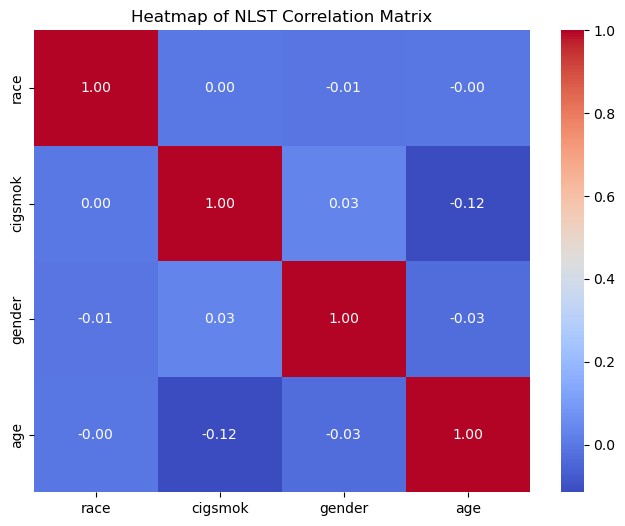

In [66]:
import seaborn as sns

import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = Lungcancertype_main[['race', 'cigsmok', 'gender', 'age']].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Add labels and title
plt.title("Heatmap of NLST Correlation Matrix")
plt.show()

In [168]:
Negative_data.__len__()

32938

In [169]:
Negative_data['Stage_AJCC7th'].value_counts() 

Stage_AJCC7th
No Lung Cancer    32938
Name: count, dtype: int64

## NLST-Seg Dicom CT scan Visualization

In [118]:
import nibabel as nib
import matplotlib.pyplot as plt

In [119]:
def Find_slice_algorithm(mask,nii_format = True):
    slices = []
    if nii_format:
        depth = mask.shape[2]
        slice_position = 0
        while slice_position < depth:
            if mask[:,:,slice_position].max() == 1:
                slices.append(slice_position)
            slice_position+=1
    else:
        for index,item in enumerate(mask):
            if item.max() > 0:
                slices.append(index)
    return slices

In [120]:
def print_dicom_no_mask(array,rows,columns,index_change = 0,figsize=(30,20),nii_format = False):
    fig, axis = plt.subplots(rows,columns, figsize = figsize)
    slice_counter = 0
    if nii_format:
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[:,:,slice_counter+index_change],cmap ='grey')
                slice_counter+=1    
    else:
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[slice_counter + index_change],cmap ='grey')

                slice_counter+=1
        
def print_dicom(array,array2,rows,columns,index_change = 0,alpha = 0.5,figsize=(30,20),nii_format = False):
    fig, axis = plt.subplots(rows,columns, figsize = (30,20))
    slice_counter = 0
    if nii_format:
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[:,:,slice_counter+index_change],cmap ='grey')
                axis[i][j].imshow(array2[:,:,slice_counter +index_change],alpha = alpha)
                slice_counter+=1    
    else:
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[slice_counter + index_change],cmap ='grey')
                axis[i][j].imshow(array2[slice_counter + index_change],alpha = alpha)

                slice_counter+=1


def print_dicom_no_mask_with_det(array,df,pid,rows,columns,index_change = 0,figsize=(30,20),nii_format = False):
    fig, axis = plt.subplots(rows,columns, figsize = figsize)
    slice_counter = 0
    if nii_format:
        print(f"PID {pid} info: ")
        print(df[df['ID']==pid])
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[:,:,slice_counter+index_change],cmap ='grey')
                slice_counter+=1    
    else:
        print(f"PID {pid} info: ")
        print(df[df['ID']==pid])
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[slice_counter + index_change],cmap ='grey')

                slice_counter+=1

def print_dicom_with_det(array,array2,df,pid,rows,columns,index_change = 0,alpha = 0.5,figsize=(30,20),nii_format = False):
    fig, axis = plt.subplots(rows,columns, figsize = (30,20))
    slice_counter = 0
    if nii_format:
        print(f"PID {pid} info: ")
        print(df[df['ID']==pid][1:])
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[:,:,slice_counter+index_change],cmap ='grey')
                axis[i][j].imshow(array2[:,:,slice_counter +index_change],alpha = alpha)
                slice_counter+=1    
    else:
        for i in range(rows):
            for j in range(columns):
                axis[i][j].imshow(array[slice_counter + index_change],cmap ='grey')
                axis[i][j].imshow(array2[slice_counter + index_change],alpha = alpha)

                slice_counter+=1


In [121]:
Positive_data_segmented = Positive_data[['ID', 'race', 'cigsmok', 'gender', 'age','Stage AJCC7th']]
Positive_data_segmented.iloc[:,1:]

,race,cigsmok,gender,age,Stage AJCC7th
0,1,1,2,61,Stage IA
1,1,0,1,68,Stage IA
2,1,0,1,65,Stage IA
3,1,0,2,60,Stage IA
4,1,1,2,60,Stage IA
...,...,...,...,...,...
592,1,1,2,72,Stage IIIA
593,2,1,1,66,Stage IV
594,1,0,2,74,Stage IV
595,1,0,1,66,Stage IA


In [125]:
picked_lung_cancer_stage = Positive_data_segmented[Positive_data_segmented['Stage AJCC7th']=='Stage IA']['ID'].to_numpy()


In [126]:
Positive_data_segmented

,ID,race,cigsmok,gender,age,Stage AJCC7th
0,100012,1,1,2,61,Stage IA
1,100147,1,0,1,68,Stage IA
2,100158,1,0,1,65,Stage IA
3,100242,1,0,2,60,Stage IA
4,100280,1,1,2,60,Stage IA
...,...,...,...,...,...,...
592,218307,1,1,2,72,Stage IIIA
593,218357,2,1,1,66,Stage IV
594,218368,1,0,2,74,Stage IV
595,218391,1,0,1,66,Stage IA


In [127]:
Positive_data_segmented['Stage AJCC7th'].value_counts()

Stage AJCC7th
Stage IA      315
Stage IIIA     73
Stage IV       70
Stage IB       63
Stage IIA      43
Stage IIB      18
Stage IIIB     15
Name: count, dtype: int64


 |de_stag_7thed|    |   |   |                    
 | --- | --- | --- | --- |
 | AJCC 7th edition stage | Stage of first primary lung cancer, based on AJCC 7th edition stage. | .M = "Missing"<br>.N = "Not Applicable"<br>110 = "Stage IA"<br>120 = "Stage IB"<br>210 = "Stage IIA"<br>220 = "Stage IIB"<br>310 = "Stage IIIA"<br>320 = "Stage IIIB"<br>400 = "Stage IV"<br>900 = "Occult Carcinoma"<br>999 = "Unknown, cannot be assessed" |

In [128]:
NLSTSEG_directory = sorted(list(Path("G:/My Drive/NLST_seg").iterdir()))[1:]
list(list(NLSTSEG_directory[0].iterdir())[0].iterdir()).__len__()

100

In [129]:
NLST_drive_picked_positives = []
for item in NLSTSEG_directory:
    inner_items = list(list(item.iterdir())[0].iterdir())
    NLST_drive_picked_positives.extend(inner_items)


In [130]:
NLST_drive_picked_positives.__len__()

605

In [131]:
NLST_drive_picked_positives[0]

WindowsPath('G:/My Drive/NLST_seg/2_LungTumor/NLSTseg_2_LungTumor/100012')

In [132]:
picked_file = NLST_drive_picked_positives[93]

In [133]:
NLST_picked_file = list(picked_file.iterdir())
NLST_picked_file

[WindowsPath('G:/My Drive/NLST_seg/2_LungTumor/NLSTseg_2_LungTumor/108611/108611_CT.nii.gz'),
 WindowsPath('G:/My Drive/NLST_seg/2_LungTumor/NLSTseg_2_LungTumor/108611/108611_tumor.nii.gz')]

In [134]:
img = nib.load(NLST_picked_file[0]).get_fdata()
mask = nib.load(NLST_picked_file[1]).get_fdata()
img_reorientated = np.transpose(img,(2,1,0))[::-1]
mask_reorientated = np.transpose(mask,(2,1,0))[::-1]

In [135]:
img_pid = int(str(picked_file)[-6:])
img_pid

108611

In [136]:
mask_tumor_slices = Find_slice_algorithm(mask_reorientated,False)
mask_tumor_slices[6]

109

In [137]:
width,height,depth = mask.shape

(width,height,depth)

(512, 512, 135)

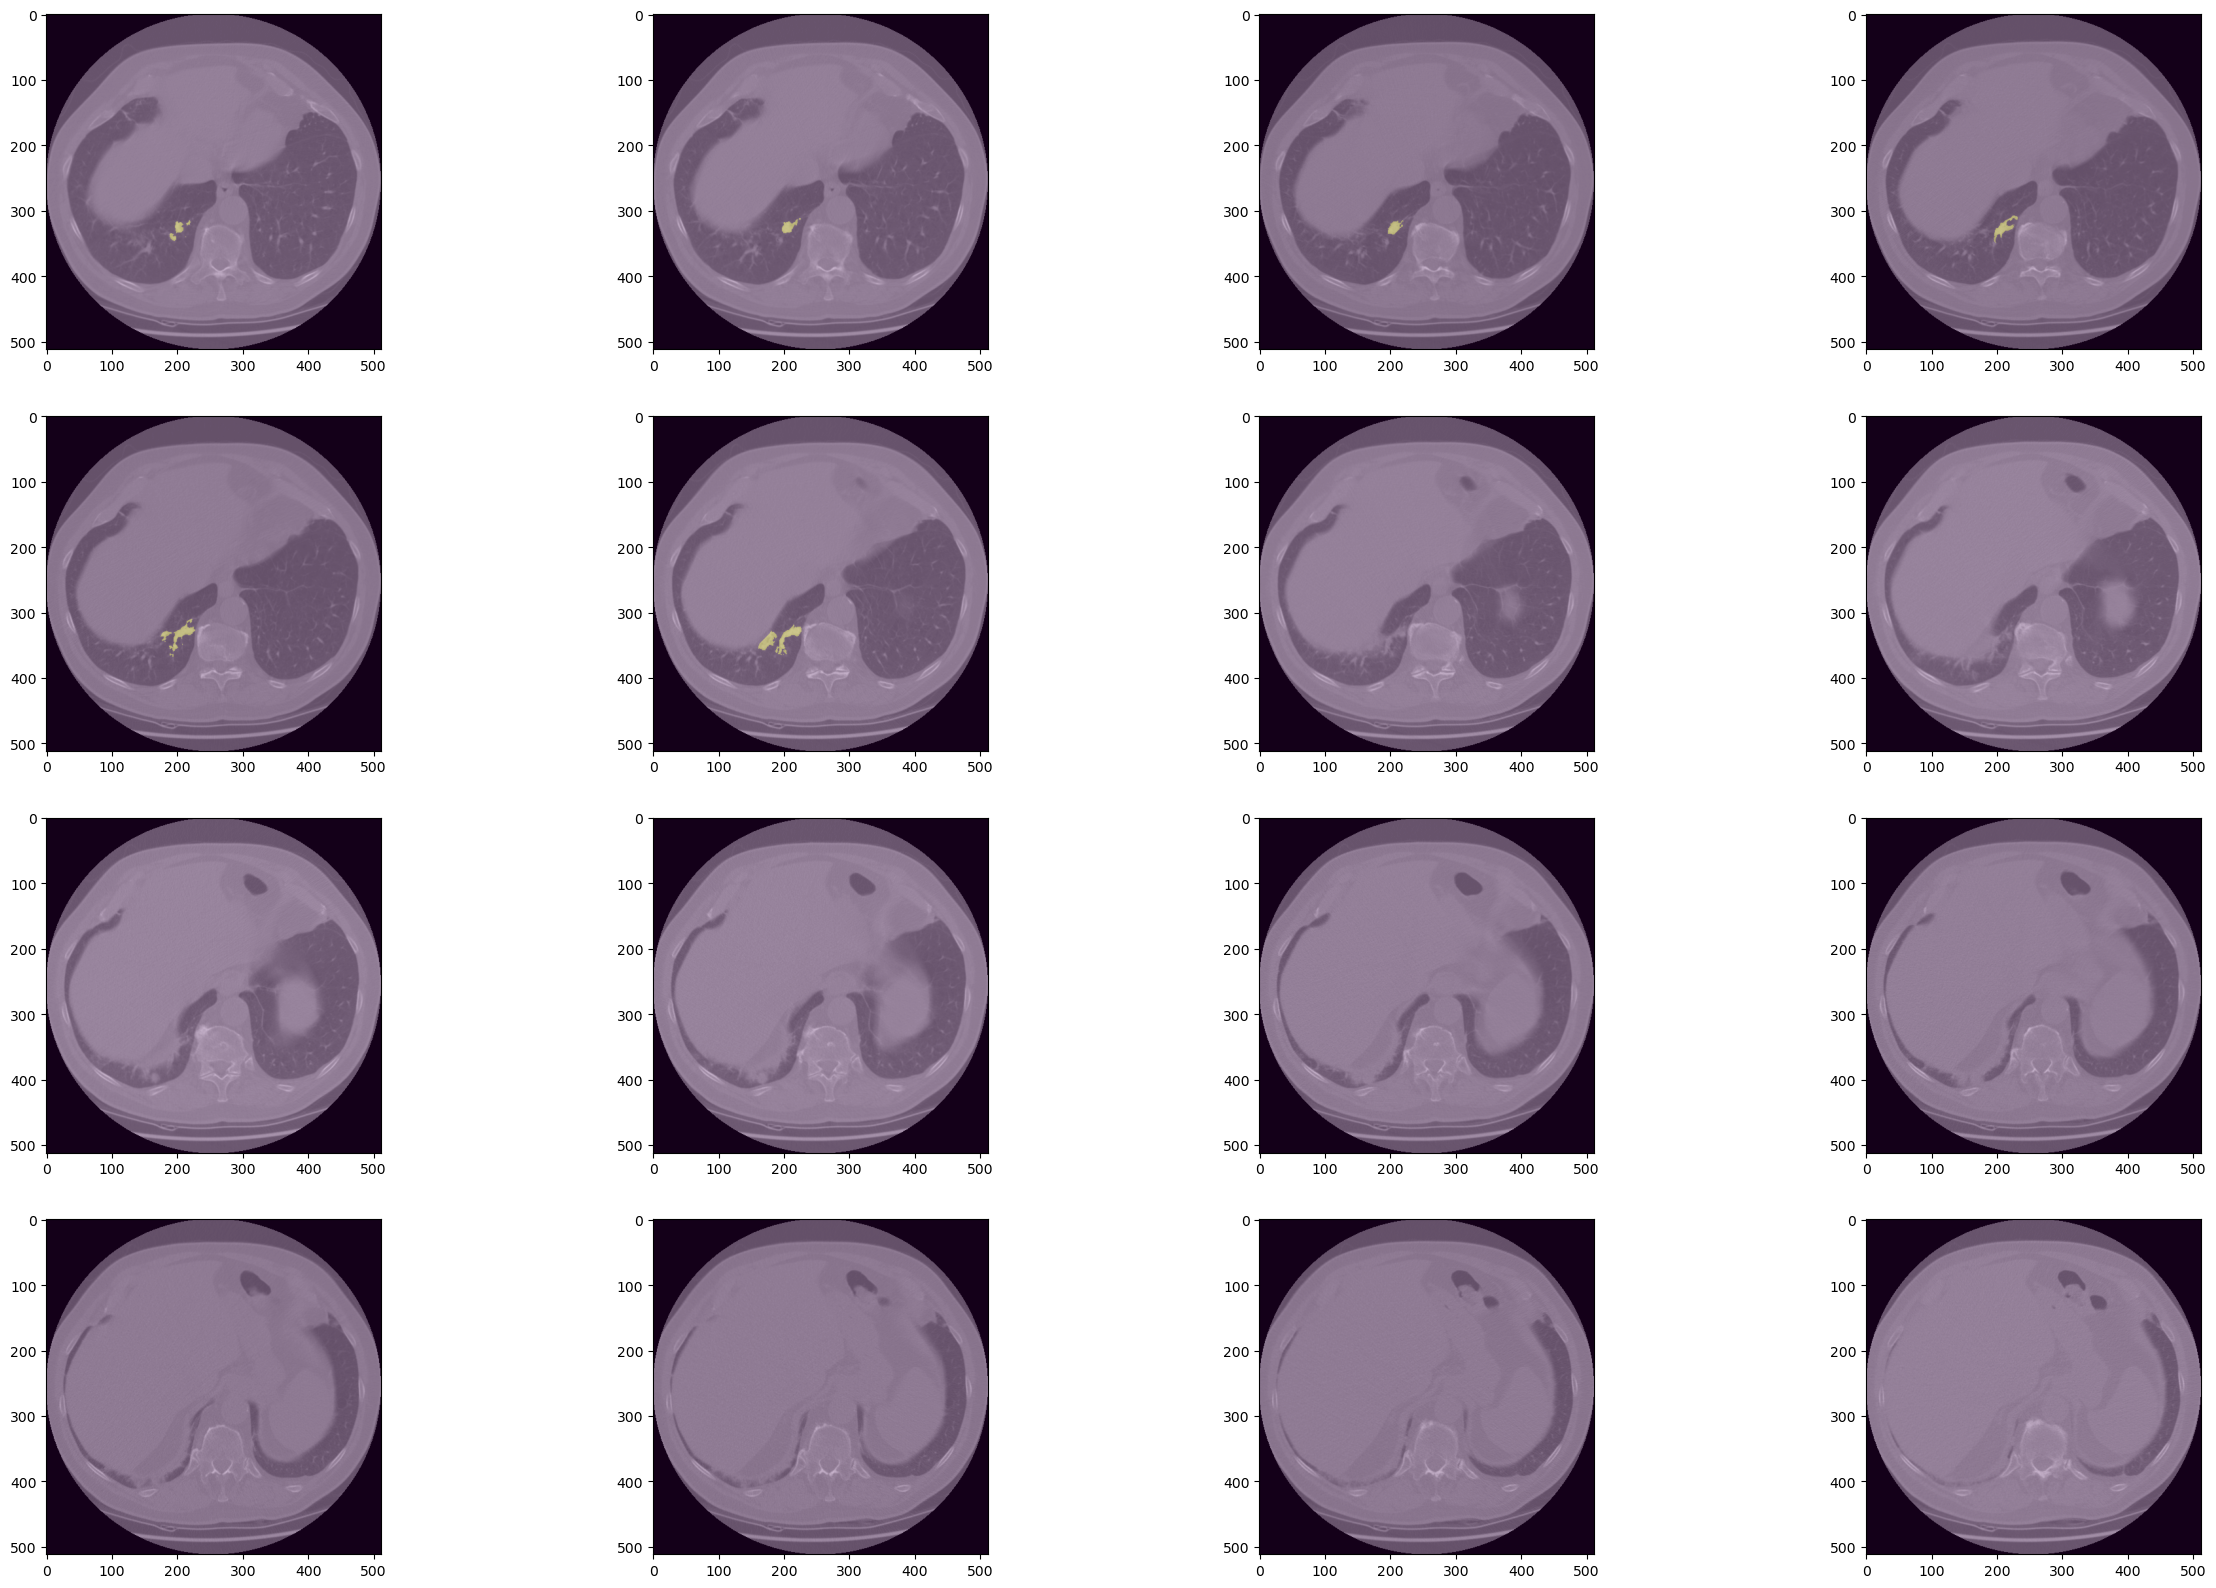

In [138]:
print_dicom(img_reorientated,mask_reorientated,4,4,mask_tumor_slices[6],alpha=0.3,nii_format=False)

PID 108611 info: 
        ID  race  cigsmok  gender  age Stage AJCC7th
93  108611     1        1       1   73      Stage IA


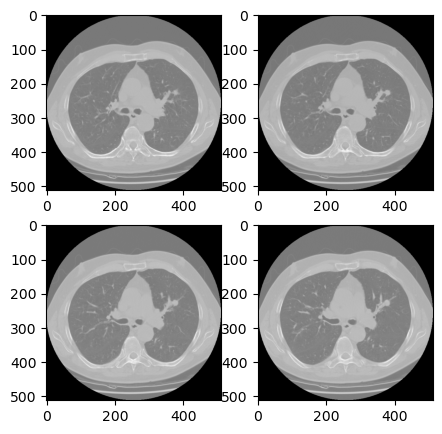

In [139]:
print_dicom_no_mask_with_det(img_reorientated,Positive_data_segmented,img_pid,2,2,mask_tumor_slices[0],nii_format=False,figsize=(5,5))

In [140]:
img_reorientated.shape

(135, 512, 512)

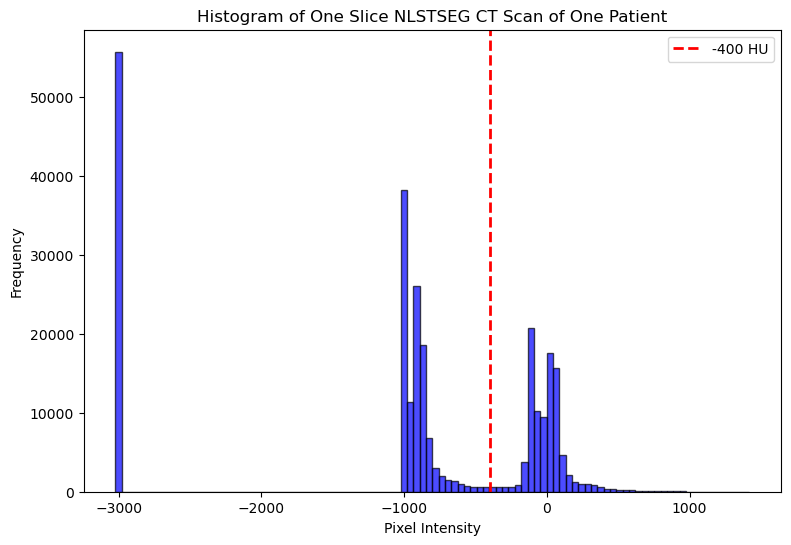

In [152]:
# Select a slice from img_reorientated
slice_index = 40  # Replace with the desired slice index
selected_slice = img_reorientated[slice_index]

# Plot the histogram
plt.figure(figsize=(9, 6))
plt.hist(selected_slice.ravel(), bins=100, color='blue', alpha=0.7, edgecolor='black')
plt.title(f'Histogram of One Slice NLSTSEG CT Scan of One Patient')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Add a vertical line at -400
plt.axvline(x=-400, color='red', linestyle='dashed', linewidth=2, label='-400 HU')

# Add a legend
plt.legend()

plt.show()

In [102]:
Positive_data_segmented[Positive_data_segmented['ID']==img_pid]

,ID,race,cigsmok,gender,age,Stage AJCC7th
93,108611,1,1,1,73,Stage IA


## Negative NLST patient CT scan Visualization

In [122]:
import pydicom as pyf
from tqdm import tqdm
import pydicom as pyf
from concurrent.futures import ThreadPoolExecutor, as_completed

In [123]:
def process_dcm_file(item, convert_hu=True):
    """Processes a single DICOM file."""
    try:
        dicom_info = pyf.dcmread(item, stop_before_pixels=True) # Read metadata first
        pixel_array = pyf.dcmread(item).pixel_array # Then read pixel data
        
        if convert_hu:
            slope = float(dicom_info.RescaleSlope)
            intercept = float(dicom_info.RescaleIntercept)
            pixel_array = pixel_array * slope + intercept
            
        return pixel_array, dicom_info
    except Exception as e:
        print(f"Could not process {item}: {e}")
        return None, None

def DCMReader3D_Fast(array, dicom_info=False, convert_hu=True,workers = 12):
    """Faster, parallel version of the DICOM reader."""
    array_matrix = [None] * len(array)
    array_data = [None] * len(array)

    # Use a ThreadPoolExecutor to fetch files in parallel
    with ThreadPoolExecutor(max_workers=workers) as executor:
        future_to_index = {
            executor.submit(process_dcm_file, item, convert_hu): i
            for i, item in enumerate(array)
        }
        
        # Use tqdm to show progress as files complete
        for future in tqdm(as_completed(future_to_index), total=len(array), desc="Processing Files"):
            index = future_to_index[future]
            pixel_data, info = future.result()
            if pixel_data is not None:
                array_matrix[index] = pixel_data
                array_data[index] = info

    # Filter out any failed reads
    array_matrix = [arr for arr in array_matrix if arr is not None]
    array_data = [info for info in array_data if info is not None]

    # --- The rest of your logic remains the same ---
    final_matrix = np.array(array_matrix)

    unprocessed_data = 1 if len(array_matrix) < len(array) else 0

    if unprocessed_data == 1:
        more25 = 1
        z_axis_neg = 0
    else:
        more25 = 1 if float(array_data[0].SliceThickness) > 2.5 else 0
        z_axis_neg = 1 if float(array_data[0].ImagePositionPatient[2]) - float(array_data[1].ImagePositionPatient[2]) < 0 else 0

    if z_axis_neg:
        final_matrix = final_matrix[::-1]

    if dicom_info:
        return final_matrix, array_data, z_axis_neg, more25,unprocessed_data
    else:
        return final_matrix

In [153]:
NLST_drive_picked_sure_negatives = list(list(Path("G:/My Drive/NLST_neg").iterdir())[1].iterdir())[1:]
NLST_drive_picked_sure_negatives


[WindowsPath('G:/My Drive/NLST_neg/NLST/100002'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100009'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100010'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100014'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100015'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100020'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100024'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100030'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100031'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100032'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100037'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100041'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100045'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100046'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100051'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100064'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100065'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100067'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100075'),


In [154]:
NLST_drive_picked_sure_negatives.__len__()

1001

In [155]:
list(sorted(list(sorted(list(NLST_drive_picked_sure_negatives[12].iterdir()))[0].iterdir()))[1].iterdir())

[WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-001.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-002.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-003.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-004.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-005.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-006.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-1999-NA-NLST-LSS-28055/2.000000-0OPAGELSQXD3802.512056.00.11.5-27362/1-007.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043/01-02-19

In [156]:
list(list(NLST_drive_picked_sure_negatives[4].iterdir())[1].iterdir())[0]

WindowsPath('G:/My Drive/NLST_neg/NLST/100015/01-02-1999-NA-NLST-LSS-53203/0.000000-0OPLPHMX8000UNK500na90null1.0null-86563')

In [157]:
str(list(list(list(NLST_drive_picked_sure_negatives[4].iterdir())[1].iterdir())[1].iterdir())[0])

'G:\\My Drive\\NLST_neg\\NLST\\100015\\01-02-1999-NA-NLST-LSS-53203\\0.000000-0OPAPHMX8000C3473.212039.00.01.75-12493\\1-001.dcm'

In [162]:
NLST_CT_Scans = list(sorted(list(sorted(list(NLST_drive_picked_sure_negatives[0].iterdir()))[0].iterdir()))[1].iterdir())
NLST_CT_Scans

[WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-001.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-002.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-003.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-004.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-005.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-006.dcm'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100002/01-02-1999-NA-NLST-LSS-55322/1.000000-0OPAGELSPLUSLUNG3602.512080.00.11.5-04792/1-007.dcm'),
 WindowsPath('G:/My 

In [163]:
re.split('-',str(NLST_CT_Scans[100]))[-2][-1]

'1'

In [166]:
slices = DCMReader3D_Fast(NLST_CT_Scans, dicom_info=False)

Processing Files: 100%|██████████| 126/126 [00:10<00:00, 12.17it/s]


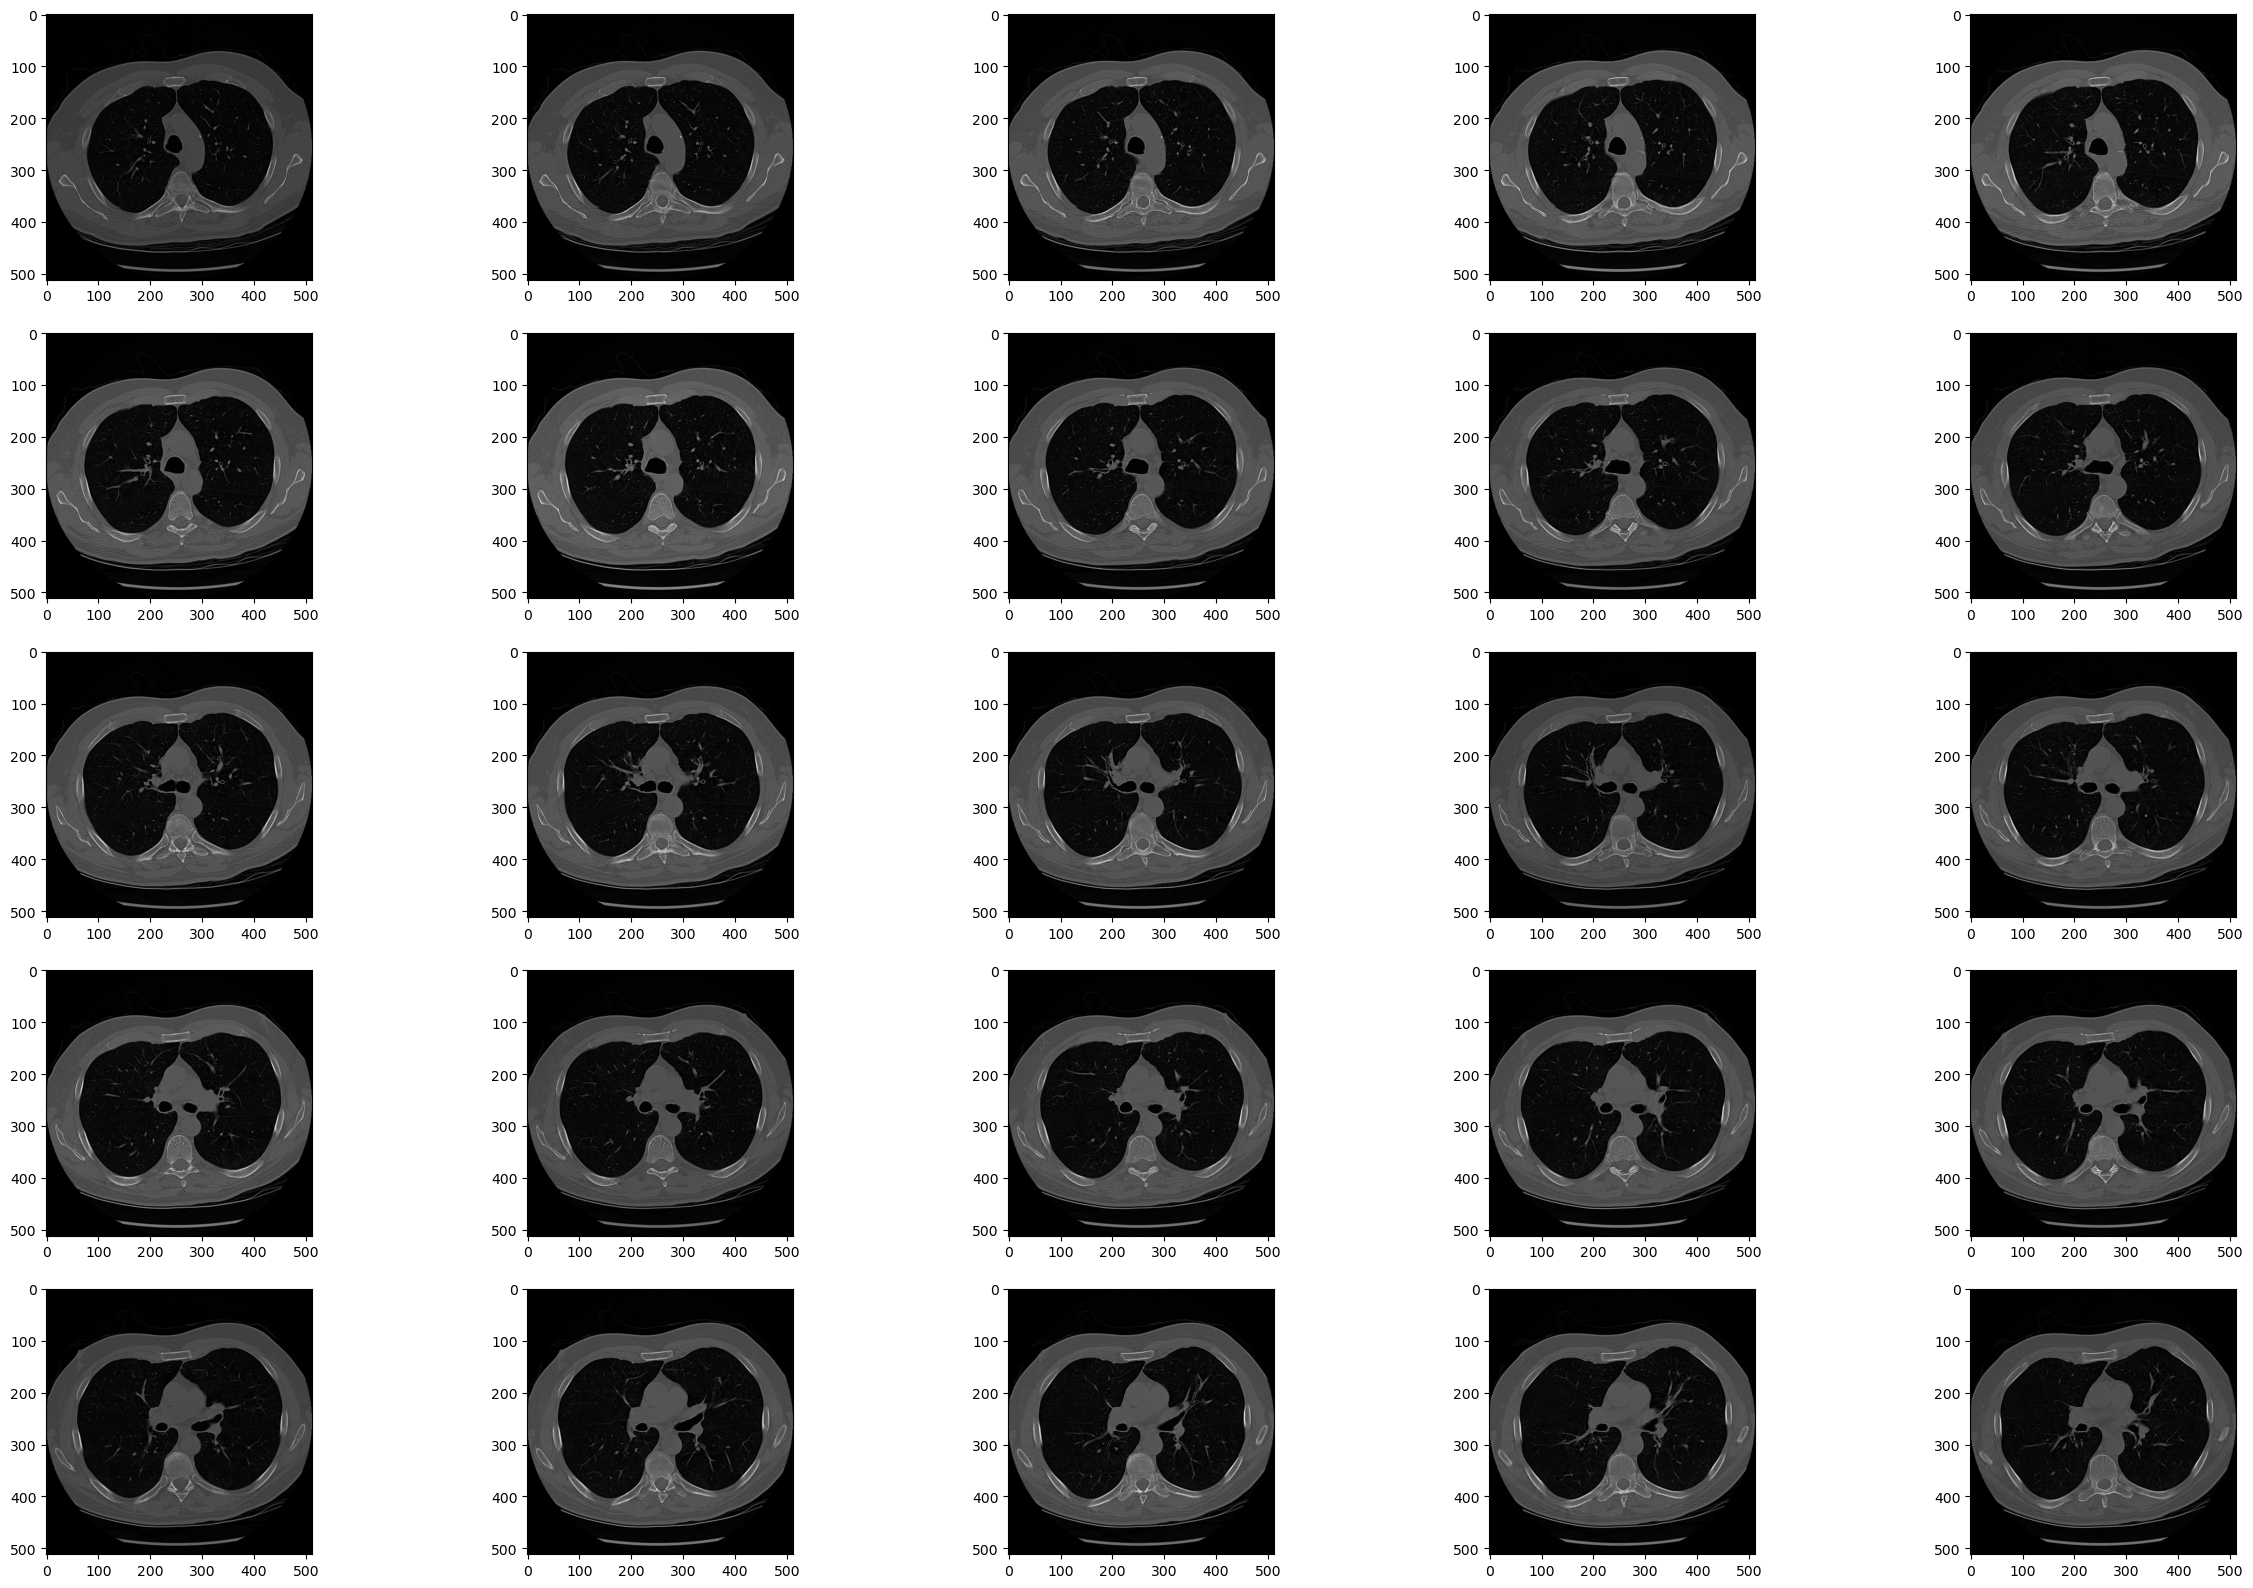

In [169]:
print_dicom_no_mask(slices,5,5,40,nii_format=False)

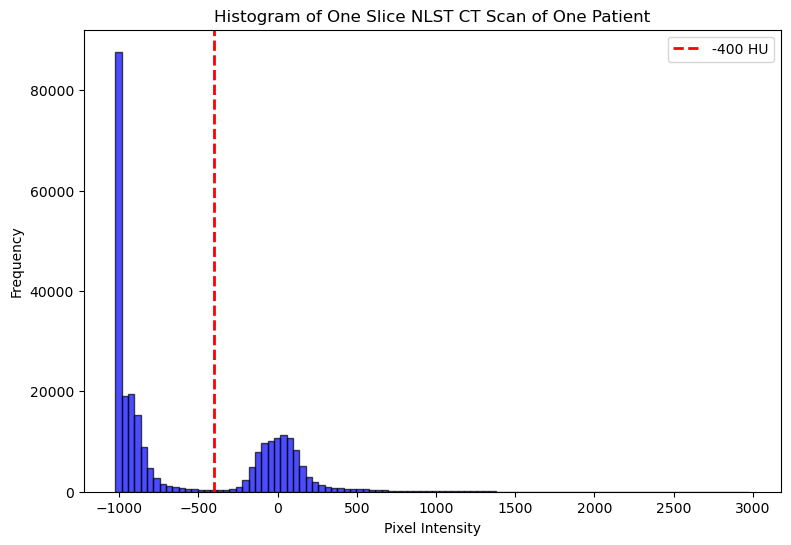

In [173]:
# Select a slice from img_reorientated
slice_index = 40 # Replace with the desired slice index
selected_slice = slices[slice_index]

# Plot the histogram
plt.figure(figsize=(9, 6))
plt.hist(selected_slice.ravel(), bins=100, color='blue', alpha=0.7, edgecolor='black')
plt.title(f'Histogram of One Slice NLST CT Scan of One Patient')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Add a vertical line at -400
plt.axvline(x=-400, color='red', linestyle='dashed', linewidth=2, label='-400 HU')

# Add a legend
plt.legend()

plt.show()

# Summarized CNN and EHR data 

In [124]:
import pandas as pd 
import numpy as np
import h5py

In [125]:
def Saveh5(directory,annotated_data,pid_data,compression_level = 5):
    with h5py.File(directory + '.h5', 'w') as hf:
        # The key is adding the compression arguments
        # compression_opts is the gzip level (1-9), 9 is max compression
        hf.create_dataset('image_data', data=annotated_data, compression='gzip', compression_opts=compression_level)
        hf.create_dataset('pid_data',data=pid_data)

def Loadh5(directory):
    with h5py.File(directory, 'r') as hf:
        # Accessing the dataset is the same as always
        retrieved_data = hf['image_data'][:] 
        pid_data = hf['pid_data'][:]
    return retrieved_data,pid_data


## Save File Algorithms & Watershed Algorithms

In [126]:
from scipy.ndimage import  zoom
from IPython.display import clear_output
from skimage import measure, segmentation
import scipy
from tqdm import tqdm

In [127]:
def generate_markers(image,hu_limit: int = -400):
    #Creation of the internal Marker
    marker_internal = image < hu_limit
    marker_internal = segmentation.clear_border(marker_internal)
    marker_internal_labels = measure.label(marker_internal)
    areas = [r.area for r in measure.regionprops(marker_internal_labels)]
    areas.sort()
    if len(areas) > 2:
        for region in measure.regionprops(marker_internal_labels):
            if region.area < areas[-2]:
                for coordinates in region.coords:                
                       marker_internal_labels[coordinates[0], coordinates[1]] = 0
    marker_internal = marker_internal_labels > 0
    #Creation of the external Marker
    external_a = scipy.ndimage.binary_dilation(marker_internal, iterations=10)
    external_b = scipy.ndimage.binary_dilation(marker_internal, iterations=55)
    marker_external = external_b ^ external_a
    #Creation of the Watershed Marker matrix
    marker_watershed = np.zeros((512, 512), dtype=np.int16)
    marker_watershed += marker_internal * 255
    marker_watershed += marker_external * 128
    
    return marker_internal, marker_external, marker_watershed

def seperate_lungs(image,hu_limit: int = -600,mini_output:bool = True):
    #Creation of the markers as shown above:
    marker_internal, marker_external, marker_watershed = generate_markers(image,hu_limit=hu_limit)
    
    #Creation of the Sobel-Gradient
    sobel_filtered_dx = scipy.ndimage.sobel(image, 1)
    sobel_filtered_dy = scipy.ndimage.sobel(image, 0)
    sobel_gradient = np.hypot(sobel_filtered_dx, sobel_filtered_dy)
    sobel_gradient *= 255.0 / np.max(sobel_gradient)
    
    #Watershed algorithm
    watershed = segmentation.watershed(sobel_gradient, marker_watershed)
    
    #Reducing the image created by the Watershed algorithm to its outline
    outline = scipy.ndimage.morphological_gradient(watershed, size=(3,3))
    outline = outline.astype(bool)
    
    #Performing Black-Tophat Morphology for reinclusion
    #Creation of the disk-kernel and increasing its size a bit
    blackhat_struct = [[0, 0, 1, 1, 1, 0, 0],
                       [0, 1, 1, 1, 1, 1, 0],
                       [1, 1, 1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1, 1, 1],
                       [0, 1, 1, 1, 1, 1, 0],
                       [0, 0, 1, 1, 1, 0, 0]]
    
    blackhat_struct = scipy.ndimage.iterate_structure(blackhat_struct, 8)
    #Perform the Black-Hat
    outline += scipy.ndimage.black_tophat(outline, structure=blackhat_struct)
    
    #Use the internal marker and the Outline that was just created to generate the lungfilter
    lungfilter = np.bitwise_or(marker_internal, outline)
    #Close holes in the lungfilter
    #fill_holes is not used here, since in some slices the heart would be reincluded by accident
    lungfilter = scipy.ndimage.binary_closing(lungfilter, structure=np.ones((7,7)), iterations=3)
    
    #Apply the lungfilter (note the filtered areas being assigned -2000 HU)
    segmented = np.where(lungfilter == 1, image, -2000*np.ones((512, 512)))

    #### nodule
    lung_nodule_1 = np.bitwise_or(marker_internal, image.astype(int))
    lung_nodule = np.where(lungfilter == 1, lung_nodule_1, np.zeros((512, 512)))

    if mini_output:
        return lung_nodule
    else:
        return segmented, lung_nodule, lungfilter, outline, watershed, sobel_gradient, marker_internal, marker_external, marker_watershed,image

## GETTING POSITIVE CANCER DATA

In [79]:
Positive_data['Stage AJCC7th'].unique()

array(['Stage IA', 'Stage IB', 'Stage IIA', 'Stage IIIA', 'Stage IV',
       'Stage IIIB', 'Stage IIB'], dtype=object)

In [80]:
len(Positive_data['ID'].tolist())

597

In [92]:
NLST_drive_picked_positives_segmented = [item for item in NLST_drive_picked_positives if int(str(item)[-6:]) in Positive_data['ID'].tolist()]

In [93]:
NLST_drive_picked_positives_segmented.__len__()

597

In [94]:
int(str(NLST_drive_picked_positives_segmented[0])[-6:])

100012

In [153]:
def NLST_seg_2DTumorCollector(Lungcancerstages,main_directory,hu_limit=-400,reshape = 224,segmented_data = False):          
    file_directory = Path("initial_preprocessing")
    if segmented_data:
        directory = file_directory / 'lung_cancer_positive_segmented.h5'
        directory_metadata = file_directory / 'lung_cancer_positive_segmented_metadata.npy'
    else:
        directory = file_directory / 'lung_cancer_positive.h5'
        directory_metadata = file_directory / 'lung_cancer_positive_metadata.npy'
    if directory.exists():
        print(f"Loading existing file: {directory}")
        Annotated_pid_slices,Annotated_pid_slices_pid = Loadh5(str(directory))
        Annotated_pid_slices = list(Annotated_pid_slices)
        Annotated_pid_slices_pid = list(Annotated_pid_slices_pid)
        Annotated_pid_metadata = list(np.load(str(directory_metadata),allow_pickle=True))
    else:
        print(f"No existing file found at: {directory}. Starting processing...")
        Annotated_pid_slices = []
        Annotated_pid_slices_pid = []
        Annotated_pid_metadata = []



    for drive_item in tqdm(Lungcancerstages,desc="Loaded_Tumors",total=len(Lungcancerstages)):
        drive_item_index = int(str(drive_item)[-6:])
        if directory.exists():
            directory_index = 0
            if drive_item_index in list(set(Annotated_pid_slices_pid)):
                if (directory_index % 10) == 0:
                    clear_output(wait=True)
                print(f"PID: {drive_item_index} already processed. Skipping...")
                directory_index += 1

                continue
                
        NLST_picked_file = list(drive_item.iterdir())
        img_reorientated = np.transpose(nib.load(NLST_picked_file[0]).get_fdata(dtype=np.float32),(2,1,0))[::-1]
        mask_reorientated = np.transpose(nib.load(NLST_picked_file[1]).get_fdata(dtype=np.float32),(2,1,0))[::-1]
        depth, height, width = img_reorientated.shape
        zoom_factors = [
            reshape / height, # Height factor
            reshape / width  # Width factor
        ]
        mask_tumor_slices = Find_slice_algorithm(mask_reorientated,False)
        for mask_index,mask_item in enumerate(mask_tumor_slices):
            print(f"Mask Item: {mask_index+1} / {len(mask_tumor_slices)} for PID: {drive_item_index}")
            image_picked = img_reorientated[mask_item]
            if segmented_data:
                image_picked = seperate_lungs(image_picked,hu_limit=hu_limit)
            image_picked = zoom(image_picked,zoom_factors,order=3)
            Annotated_pid_slices.append(image_picked)
            Annotated_pid_slices_pid.append(drive_item_index)
        Annotated_meta_item = {
            'pid': drive_item_index,
            'original_shape 3D': (depth,height, width),
            'reshaped_to': (len(mask_tumor_slices),224, 224),
            'slices_used': mask_tumor_slices,
            'Errors': 'NA'
        }
        Annotated_pid_metadata.append(Annotated_meta_item)
        
        print("Saving all the pid slices so far...")
        if segmented_data:
            Saveh5('initial_preprocessing/lung_cancer_positive_segmented',Annotated_pid_slices,Annotated_pid_slices_pid)
            np.save('initial_preprocessing/lung_cancer_positive_segmented_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
            clear_output(wait=True)
        else:
            Saveh5('initial_preprocessing/lung_cancer_positive',Annotated_pid_slices,Annotated_pid_slices_pid)
            np.save('initial_preprocessing/lung_cancer_positive_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
            clear_output(wait=True)
        
        

            
    print("Saving all the data...")
    if segmented_data:
        final_directory = main_directory +  '/lung_cancer_positive_segmented'
        Saveh5(final_directory,Annotated_pid_slices,Annotated_pid_slices_pid)
        np.save(final_directory + '_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
    else:
        final_directory = main_directory +  '/lung_cancer_positive'
        Saveh5(final_directory,Annotated_pid_slices,Annotated_pid_slices_pid)
        np.save(final_directory + '_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
    return None

In [107]:
NLST_seg_2DTumorCollector(NLST_drive_picked_positives_segmented,'final_preprocessed_datasets',segmented_data=True)

Loaded_Tumors: 100%|██████████| 597/597 [5:34:26<00:00, 33.61s/it] 


Saving all the data...


In [ ]:
NLST_seg_2DTumorCollector(NLST_drive_picked_positives,'final_preprocessed_datasets/lung_cancer_detection_segmented',segmented_data=False)

### GETTING NO CANCER PATIENT DATA

In [94]:
NLST_drive_picked_sure_negatives

[WindowsPath('G:/My Drive/NLST_neg/NLST/100002'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100009'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100010'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100014'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100015'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100020'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100024'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100030'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100031'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100032'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100037'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100041'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100043'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100045'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100046'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100051'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100064'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100065'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100067'),
 WindowsPath('G:/My Drive/NLST_neg/NLST/100075'),


In [95]:
def NLST_2DSliceCollector(path,outside_directory = 'Downloads',hu_limit=-400,reshape = 224,segmented_data = False,slice_per_patient = 13):          
    file_directory = Path("initial_preprocessing")
    if segmented_data:
        directory = file_directory / 'lung_cancer_negative_segmented.h5'
        directory_metadata = file_directory / 'lung_cancer_negative_segmented_metadata.npy'
    else:
        directory = file_directory / 'lung_cancer_negative.h5'
        directory_metadata = file_directory / 'lung_cancer_negative_metadata.npy'
    if directory.exists():
        print(f"Loading existing file: {directory}")
        Annotated_pid_slices,Annotated_pid_slices_pid = Loadh5(str(directory))
        Annotated_pid_slices = list(Annotated_pid_slices)
        Annotated_pid_slices_pid = list(Annotated_pid_slices_pid)
        Annotated_pid_metadata = list(np.load(str(directory_metadata),allow_pickle=True))
    else:
        print(f"No existing file found at: {directory}. Starting processing...")
        Annotated_pid_slices = []
        Annotated_pid_slices_pid = []
        Annotated_pid_metadata = []
    index_chosen = 0
    index_inside = 0
    years = ['1999','2000','2001']
    while index_chosen < len(path):
      # inital diciom processing

      directory_item = path[index_chosen]
      id_item = int(str(directory_item)[-6:])
     
      if directory.exists():
            directory_index = 0
            index_inside = len(Annotated_pid_slices_pid)
            if id_item in list(set(Annotated_pid_slices_pid)):
                if (directory_index % 10) == 0:
                    clear_output(wait=True)
                print(f"PID: {id_item} already processed. Skipping...")
                directory_index += 1
                index_chosen+=1
                continue
     
     
     
     
      print(f"Item [{index_chosen+1}/{len(path)}] Item [{index_inside+1}/{len(path)*slice_per_patient}]")
      year_chosen_loc = sorted(list(directory_item.iterdir()))
      year_check = []
      chosen_data =  []
      while True:
         get_random_year = np.random.randint(0,len(year_chosen_loc))
         if get_random_year in year_check:
               if len(year_check) == 3:
                  print(f"PID {id_item} has no year with more than 50 slices, skipping...")
                  break
               continue
         inner_year_data = list(year_chosen_loc[get_random_year].iterdir())
         for inner_year_items in inner_year_data:
               item_open = list(inner_year_items.iterdir())
               if len(item_open) > len(chosen_data):
                  chosen_data = item_open
         if len(chosen_data) < 80:
               print(f"ID {id_item} Year {years[get_random_year]} less than 50 slices, skipping...")
               continue
         else:
               break
      if len(year_check) == 3:
         print(f"Skipping PID {id_item} entirely.")
         index_chosen+=1
         Annotated_meta_item = {
            'pid': id_item,
            'year_used':  'NA',
            'original_shape 3D': (0,0, 0),
            'reshaped_to': (0,0, 0),
            'slices_used': [],
            'Errors': 'No sufficient slices'
         }
         Annotated_pid_metadata.append(Annotated_meta_item)
         continue
      NLST_CT_scan_cleaned = [item for item in chosen_data if re.split('-',str(item))[-2][-1] == '1']
      get_random_slice = np.random.randint(4,len(NLST_CT_scan_cleaned)- slice_per_patient - 21)
      NLST_CT_slices = [index for index in range(get_random_slice,get_random_slice+slice_per_patient)]
      dicom_image,data,z_pos,thickness,unprocessed = DCMReader3D_Fast(chosen_data[get_random_slice:get_random_slice+slice_per_patient],True,True,workers=5)
      if unprocessed == 1:
         depth, height, width = dicom_image.shape  
         print("Data not processed properly")
         Annotated_meta_item = {
            'pid': id_item,
            'year_used': years[get_random_year],
            'original_shape 3D': (0,0,0),
            'reshaped_to': (0,0, 0),
            'slices_used': [],
            'Errors': 'Data not processed properly'
         }
         Annotated_pid_metadata.append(Annotated_meta_item)
         print("Saving metadata so far...")
         if segmented_data:
            np.save('initial_preprocessing/lung_cancer_negative_segmented_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
            clear_output(wait=True)
         else:
            np.save('initial_preprocessing/lung_cancer_negative_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
            clear_output(wait=True)
         index_chosen+=1
         continue
         
      # process 
      for dicom_item in tqdm(dicom_image,desc="Transforming Slices",total=len(dicom_image)):
         depth, height, width = dicom_image.shape
         zoom_factors = [
                reshape / height, # Height factor
                reshape / width  # Width factor
         ]
         if segmented_data:
                dicom_item = seperate_lungs(dicom_item,hu_limit=hu_limit)
         dicom_2d_slice = zoom(dicom_item,zoom_factors,order=3)
         dicom_2d_slice = dicom_2d_slice.astype(np.float32)      
         Annotated_pid_slices.append(dicom_2d_slice)
         Annotated_pid_slices_pid.append(id_item)
         index_inside+=1
      if thickness == 1:
         Annotated_meta_item = {
            'pid': id_item,
            'year_used': years[get_random_year],
            'original_shape 3D': (len(NLST_CT_scan_cleaned),height, width),
            'reshaped_to': (len(dicom_image),224, 224),
            'slices_used': NLST_CT_slices,
            'Errors': "Thickness greater than 2.5mm"
         }
         Annotated_pid_metadata.append(Annotated_meta_item)
      else:
         Annotated_meta_item = {
            'pid': id_item,
            'year_used': years[get_random_year],
            'original_shape 3D': (len(NLST_CT_scan_cleaned),height, width),
            'reshaped_to': (len(dicom_image),224, 224),
            'slices_used': NLST_CT_slices,
            'Errors': 'NA'
         }
         Annotated_pid_metadata.append(Annotated_meta_item)



         
      print("Saving all the pid slices so far...")
      if segmented_data:
         Saveh5('initial_preprocessing/lung_cancer_negative_segmented',Annotated_pid_slices,Annotated_pid_slices_pid)
         np.save('initial_preprocessing/lung_cancer_negative_segmented_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
         clear_output(wait=True)
      else:
         Saveh5('initial_preprocessing/lung_cancer_negative',Annotated_pid_slices,Annotated_pid_slices_pid)
         np.save('initial_preprocessing/lung_cancer_negative_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
         clear_output(wait=True)
      index_chosen+=1
            
    print("Saving all the data...")
    if segmented_data:
        final_directory = outside_directory +  '/lung_cancer_negative_segmented'
        Saveh5(final_directory,Annotated_pid_slices,Annotated_pid_slices_pid)
        np.save(final_directory + '_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
    else:
         final_directory = outside_directory +  '/lung_cancer_negative'
         Saveh5(final_directory,Annotated_pid_slices,Annotated_pid_slices_pid)
         np.save(final_directory + '_metadata.npy',Annotated_pid_metadata,allow_pickle=True)
    return None


In [96]:
NLST_2DSliceCollector(NLST_drive_picked_sure_negatives,'final_preprocessed_datasets',reshape=224,segmented_data=True,slice_per_patient=12)

Saving all the data...


## Final Preprocessing

In [11]:
Annotated_positive_list,Annotated_positive_pid = Loadh5('final_preprocessed_datasets/lung_cancer_positive_segmented.h5')

In [12]:
Annotated_negative_list,Annotated_negative_pid = Loadh5('final_preprocessed_datasets/lung_cancer_negative_segmented.h5')

In [13]:
Annotated_positive_pid.__len__() # calculating 10% of total dataset for testing

7139

In [17]:
Annotated_negative_pid.__len__()

12012

In [18]:
2866 /2

1433.0

In [19]:
pd.DataFrame(Annotated_positive_pid)[0].unique()

array([100012, 100147, 100158, 100242, 100280, 100570, 100658, 100681,
       100697, 100703, 100913, 100954, 101066, 101068, 101192, 101287,
       101387, 101397, 101692, 101834, 102136, 102161, 102266, 102267,
       102488, 102537, 102581, 102658, 102660, 102676, 102736, 102746,
       102806, 103232, 103344, 103359, 103507, 103566, 103619, 103621,
       103665, 103703, 103760, 104009, 104063, 104182, 104208, 104248,
       104363, 104386, 104564, 104683, 104778, 104960, 104999, 105142,
       105165, 105340, 105352, 105540, 105562, 105713, 105767, 105771,
       105974, 106046, 106194, 106204, 106286, 106364, 106432, 106498,
       106553, 106591, 106753, 106926, 107002, 107052, 107058, 107133,
       107151, 107328, 107434, 107521, 107561, 107610, 107682, 107791,
       108061, 108245, 108352, 108420, 108543, 108611, 108670, 108766,
       108806, 109189, 109345, 109462, 109532, 109573, 109616, 109852,
       109889, 109965, 110021, 110061, 110071, 110196, 110253, 110356,
      

In [67]:
positive_slice_data = np.load('final_preprocessed_datasets/lung_cancer_positive_segmented_metadata.npy',allow_pickle=True)
positive_slice_data[:3]

array([{'pid': 100012, 'original_shape 3D': (157, 512, 512), 'reshaped_to': (13, 224, 224), 'slices_used': [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], 'Errors': 'NA'},
       {'pid': 100147, 'original_shape 3D': (116, 512, 512), 'reshaped_to': (8, 224, 224), 'slices_used': [21, 22, 23, 24, 25, 26, 27, 28], 'Errors': 'NA'},
       {'pid': 100158, 'original_shape 3D': (146, 512, 512), 'reshaped_to': (7, 224, 224), 'slices_used': [53, 54, 55, 56, 57, 58, 59], 'Errors': 'NA'}],
      dtype=object)

In [ ]:
positive_slice_data.__len__()

597

In [69]:
slice_lengths = []
postive_slice_used_diff_end = []
positive_slice_used_diff_start = []
original_shape_arr = []
for item in positive_slice_data:
    slice_lengths.append(item['reshaped_to'][0])
    postive_slice_used_diff_end.append(item['original_shape 3D'][0] - item['slices_used'][-1])
    positive_slice_used_diff_start.append(item['slices_used'][0])
    original_shape_arr.append(item['original_shape 3D'][0])

(min(postive_slice_used_diff_end), min(positive_slice_used_diff_start),np.mean(slice_lengths), np.median(slice_lengths))


(21, 4, 11.958123953098827, 8.0)

In [72]:
positive_total_slices = np.sum(original_shape_arr)
positive_total_slices

105755

In [22]:
for index,item in enumerate(positive_slice_used_diff_start):
    if item == 4:
        print(index,positive_slice_data[index])
for index,item in enumerate(postive_slice_used_diff_end):
    if item == 21:
        print(index,positive_slice_data[index])

531 {'pid': 126576, 'original_shape 3D': (79, 512, 512), 'reshaped_to': (2, 224, 224), 'slices_used': [4, 5], 'Errors': 'NA'}
93 {'pid': 108611, 'original_shape 3D': (135, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [55, 56, 57, 58, 59, 60, 109, 110, 111, 112, 113, 114], 'Errors': 'NA'}


In [61]:
NLST_seg_Patient_data[NLST_seg_Patient_data['ID'] == 100012]

,Mainfolder,ID,race,cigsmok,gender,age,cancyr,Stage AJCC7th,de_typecode,de_type
0,01_LungTumor,100012,1,1,2,61,1,Stage IA,8140.0,"Adenocarcinoma, NOS"


In [62]:
new_positive_slice_data = []
year = ['1999','2000','2001']
for item in positive_slice_data:
    canc_yr_val = NLST_seg_Patient_data[NLST_seg_Patient_data['ID'] == item['pid']]['cancyr '].values[0]
    new_positive_slice_data.append({'pid': item['pid'],
                                    'year_used': year[canc_yr_val],
                                    'original_shape 3D': item['original_shape 3D'],
                                    'reshaped_to': item['reshaped_to'],
                                    'slices_used': item['slices_used'],
                                    'Errors': item['Errors']})
    
new_positive_slice_data = np.array(new_positive_slice_data)
new_positive_slice_data
#np.save('final_preprocessed_datasets/lung_cancer_positive_segmented_metadata.npy',new_positive_slice_data,allow_pickle=True)

array([{'pid': 100012, 'year_used': '2000', 'original_shape 3D': (157, 512, 512), 'reshaped_to': (13, 224, 224), 'slices_used': [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], 'Errors': 'NA'},
       {'pid': 100147, 'year_used': '2000', 'original_shape 3D': (116, 512, 512), 'reshaped_to': (8, 224, 224), 'slices_used': [21, 22, 23, 24, 25, 26, 27, 28], 'Errors': 'NA'},
       {'pid': 100158, 'year_used': '2001', 'original_shape 3D': (146, 512, 512), 'reshaped_to': (7, 224, 224), 'slices_used': [53, 54, 55, 56, 57, 58, 59], 'Errors': 'NA'},
       {'pid': 100242, 'year_used': '1999', 'original_shape 3D': (123, 512, 512), 'reshaped_to': (3, 224, 224), 'slices_used': [17, 18, 19], 'Errors': 'NA'},
       {'pid': 100280, 'year_used': '2000', 'original_shape 3D': (155, 512, 512), 'reshaped_to': (8, 224, 224), 'slices_used': [69, 70, 71, 72, 73, 74, 75, 76], 'Errors': 'NA'},
       {'pid': 100570, 'year_used': '1999', 'original_shape 3D': (163, 512, 512), 'reshaped_to': (9, 224, 224), '

In [83]:
negative_slice_data = np.load('final_preprocessed_datasets/lung_cancer_negative_segmented_metadata.npy',allow_pickle=True)
negative_slice_data.__len__()

1001

In [74]:
negative_slice_data = np.load('final_preprocessed_datasets/lung_cancer_negative_segmented_metadata.npy',allow_pickle=True)
negative_slice_data

array([{'pid': 100002, 'year_used': '2001', 'original_shape 3D': (129, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66], 'Errors': 'NA'},
       {'pid': 100009, 'year_used': '1999', 'original_shape 3D': (156, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], 'Errors': 'NA'},
       {'pid': 100010, 'year_used': '2001', 'original_shape 3D': (137, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86], 'Errors': 'NA'},
       ...,
       {'pid': 103771, 'year_used': '2000', 'original_shape 3D': (264, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53], 'Errors': 'NA'},
       {'pid': 103781, 'year_used': '2000', 'original_shape 3D': (159, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'Errors': 'NA'},
       {'pid': 10

In [75]:
slice_lengths = []
negative_slice_used_diff_end = []
negative_slice_used_diff_start = []
neg_original_shape_arr = []
for item in negative_slice_data:
    slice_lengths.append(item['reshaped_to'][0])
    negative_slice_used_diff_end.append(item['original_shape 3D'][0] - item['slices_used'][-1])
    negative_slice_used_diff_start.append(item['slices_used'][0])
    neg_original_shape_arr.append(item['original_shape 3D'][0])
(min(negative_slice_used_diff_end), min(negative_slice_used_diff_start),np.mean(slice_lengths), np.median(slice_lengths), max(slice_lengths))


(23, 4, 12.0, 12.0, 12)

In [77]:
negative_total_slices = np.sum(neg_original_shape_arr)
negative_total_slices

148548

In [30]:
np.random.shuffle(negative_slice_data)
picked_negative_data = negative_slice_data[:595]
picked_negative_data_pid = [item['pid'] for item in picked_negative_data]
picked_negative_data_pid

[102000,
 103567,
 102847,
 103712,
 101571,
 102559,
 102547,
 101971,
 102997,
 100540,
 103392,
 100320,
 102836,
 103106,
 103561,
 103425,
 101133,
 103378,
 102187,
 101246,
 102114,
 100710,
 101418,
 102024,
 100840,
 100947,
 100413,
 103732,
 103433,
 102959,
 101334,
 100551,
 102382,
 101915,
 101416,
 100791,
 102479,
 102249,
 103265,
 100239,
 101281,
 100400,
 101230,
 103686,
 101182,
 101115,
 103511,
 102320,
 101685,
 103611,
 102612,
 103363,
 101051,
 102506,
 100091,
 100102,
 102355,
 100037,
 100879,
 103465,
 101175,
 100221,
 102088,
 100838,
 102331,
 102817,
 103182,
 103297,
 100275,
 102091,
 100442,
 101879,
 102262,
 103141,
 101165,
 101155,
 102482,
 100164,
 102260,
 101212,
 102565,
 100258,
 101108,
 100260,
 101244,
 102108,
 103781,
 102733,
 102898,
 101278,
 101458,
 101740,
 102004,
 100870,
 103037,
 101678,
 102412,
 100362,
 100253,
 103153,
 102737,
 101349,
 102317,
 101022,
 102426,
 103069,
 102134,
 103642,
 100682,
 103312,
 102025,
 

In [99]:
picked_negative_data_pid[:10]

[102000,
 103567,
 102847,
 103712,
 101571,
 102559,
 102547,
 101971,
 102997,
 100540]

In [53]:
picked_negative_data.__len__()

595

In [31]:
Annotated_negative_pid[:200]

array([100002, 100002, 100002, 100002, 100002, 100002, 100002, 100002,
       100002, 100002, 100002, 100002, 100009, 100009, 100009, 100009,
       100009, 100009, 100009, 100009, 100009, 100009, 100009, 100009,
       100010, 100010, 100010, 100010, 100010, 100010, 100010, 100010,
       100010, 100010, 100010, 100010, 100014, 100014, 100014, 100014,
       100014, 100014, 100014, 100014, 100014, 100014, 100014, 100014,
       100015, 100015, 100015, 100015, 100015, 100015, 100015, 100015,
       100015, 100015, 100015, 100015, 100020, 100020, 100020, 100020,
       100020, 100020, 100020, 100020, 100020, 100020, 100020, 100020,
       100024, 100024, 100024, 100024, 100024, 100024, 100024, 100024,
       100024, 100024, 100024, 100024, 100030, 100030, 100030, 100030,
       100030, 100030, 100030, 100030, 100030, 100030, 100030, 100030,
       100031, 100031, 100031, 100031, 100031, 100031, 100031, 100031,
       100031, 100031, 100031, 100031, 100032, 100032, 100032, 100032,
      

In [ ]:
picked_negative_data_slices_pid = []
picked_negative_data_slices_2D = []
picked_negative_data_slices_meta = []
for index,item in enumerate(Annotated_negative_pid):
    if item in picked_negative_data_pid:
        picked_negative_data_slices_pid.append(item)
        picked_negative_data_slices_2D.append(Annotated_negative_list[index])
        picked_negative_data_slices_meta.append()

picked_negative_data_slices = np.array(picked_negative_data_slices_pid)
#np.save('final_preprocessed_datasets/lung_cancer_negative_segmented_metadata.npy',picked_negative_data_slices,allow_pickle=True)
len(picked_negative_data_slices)

7140

In [33]:
picked_negative_data_slices_pid

[100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100002,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100010,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100014,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100020,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100024,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100030,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100032,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100037,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100041,
 100043,
 100043,
 100043,
 

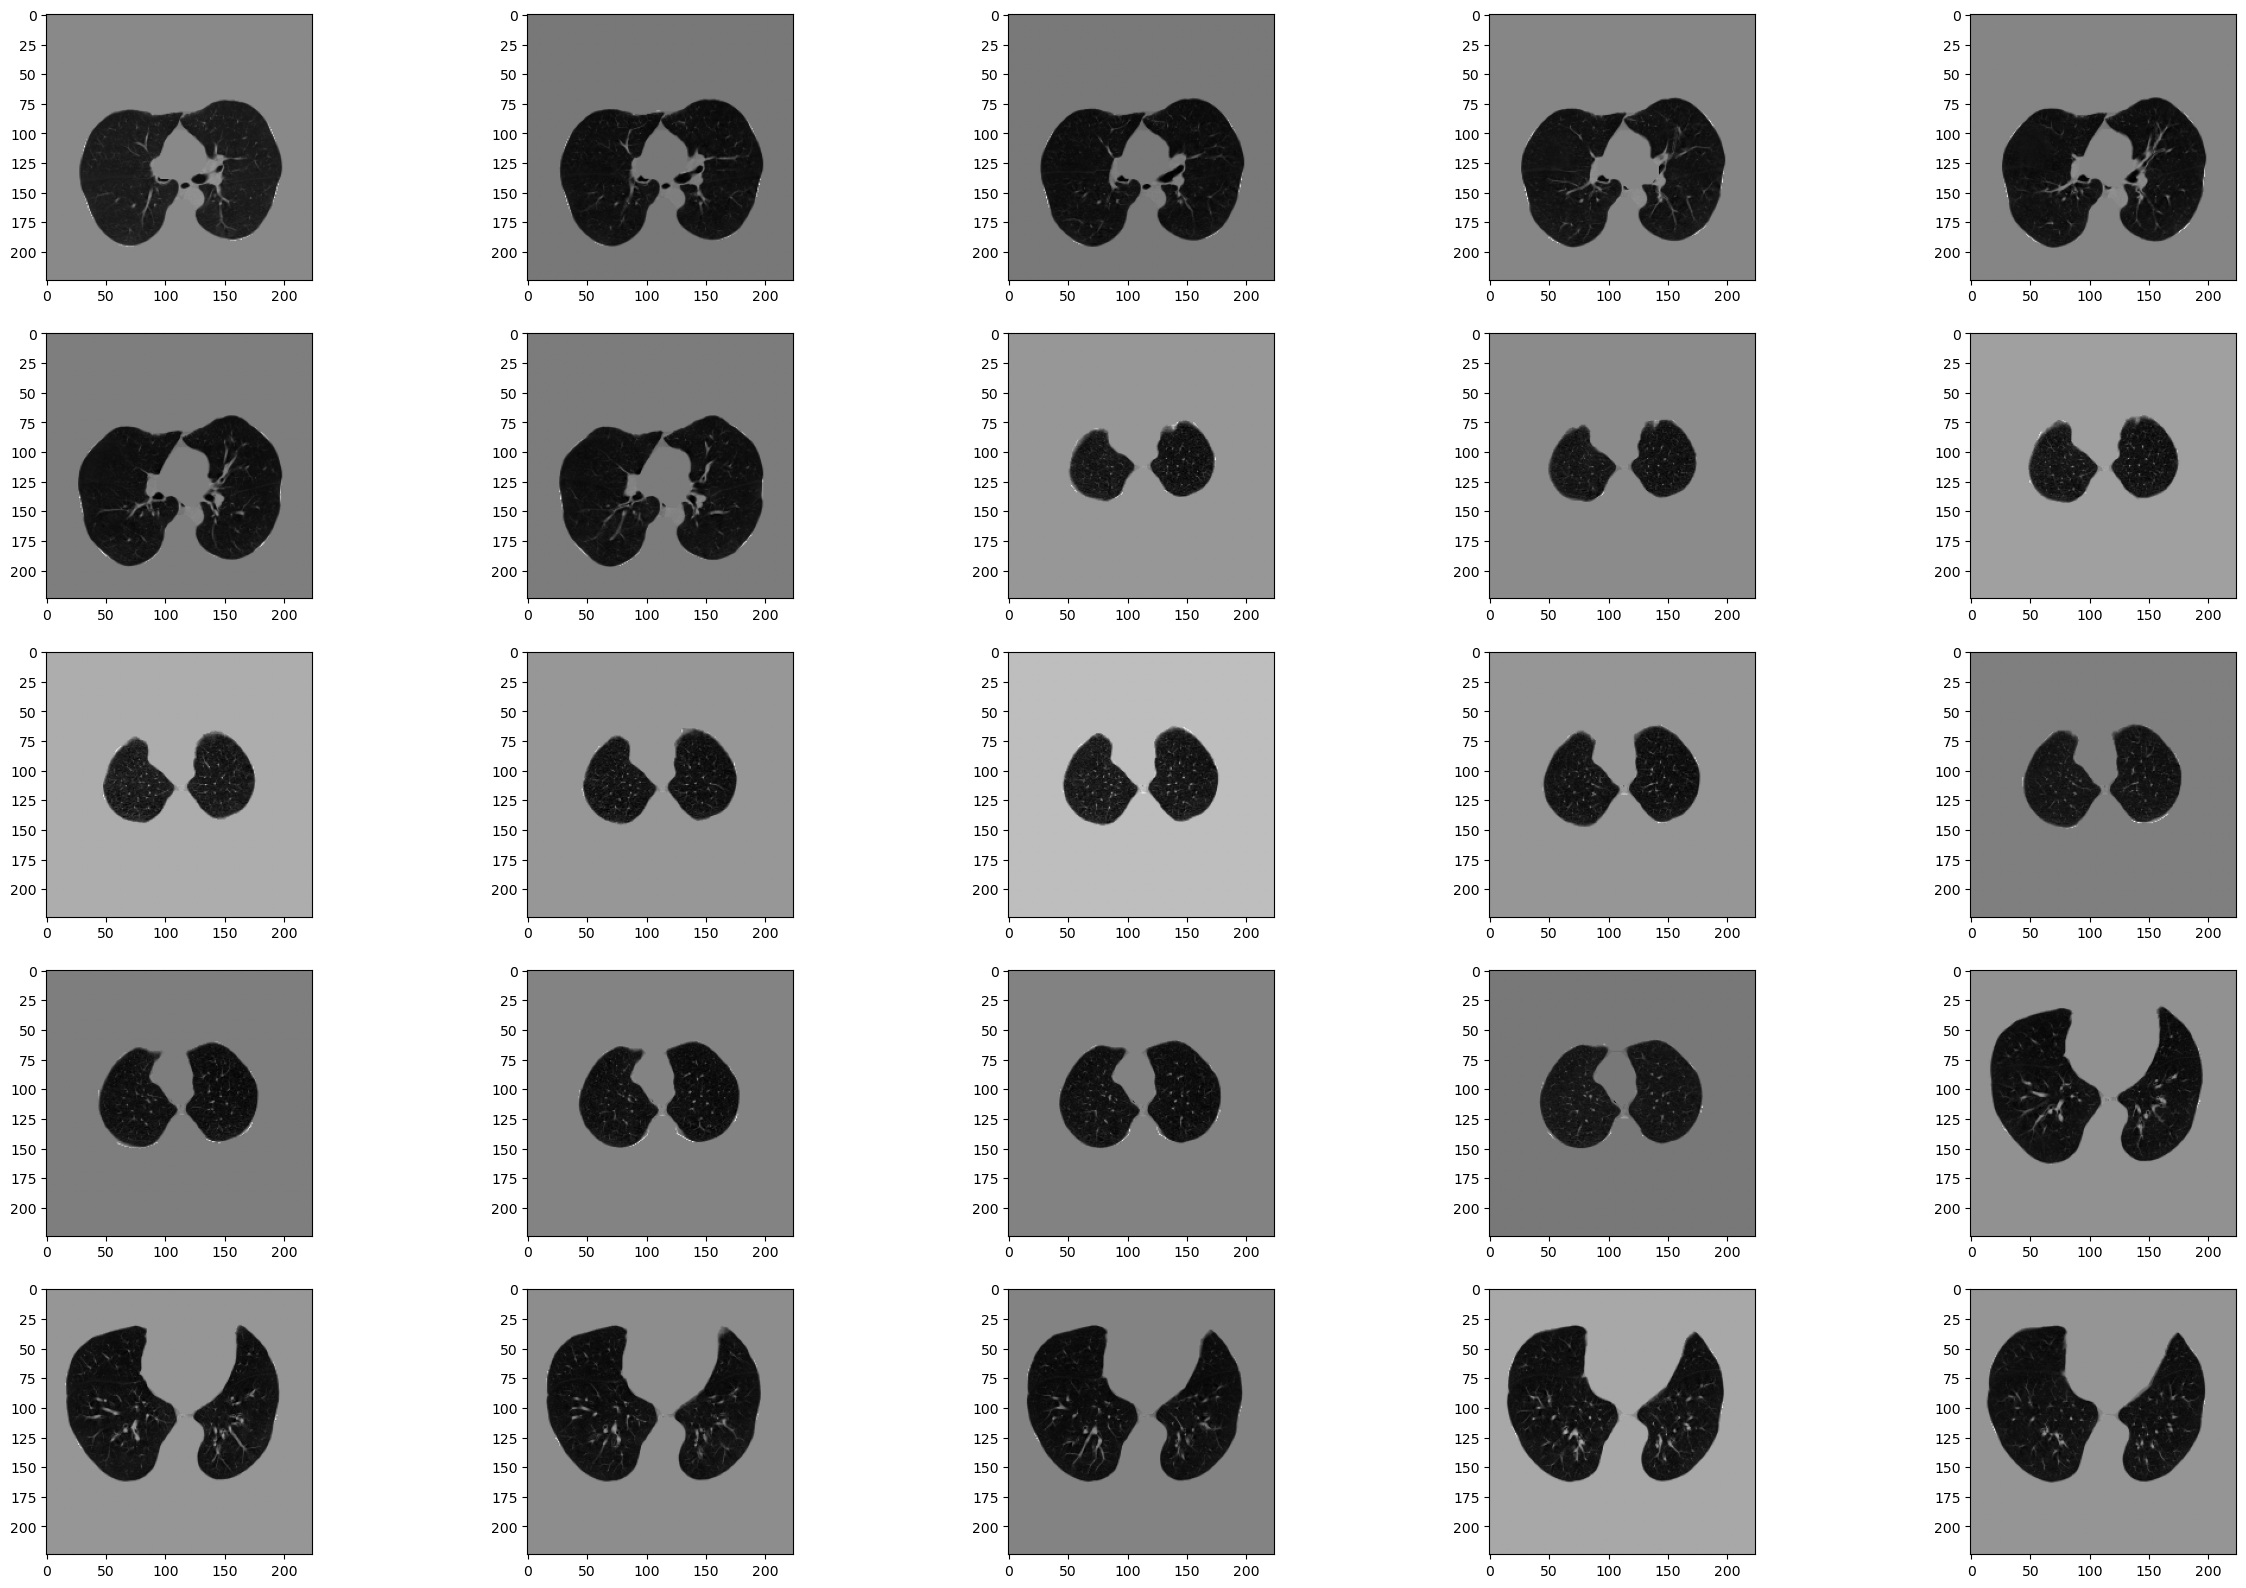

In [34]:
print_dicom_no_mask(Annotated_negative_list,5,5,5)

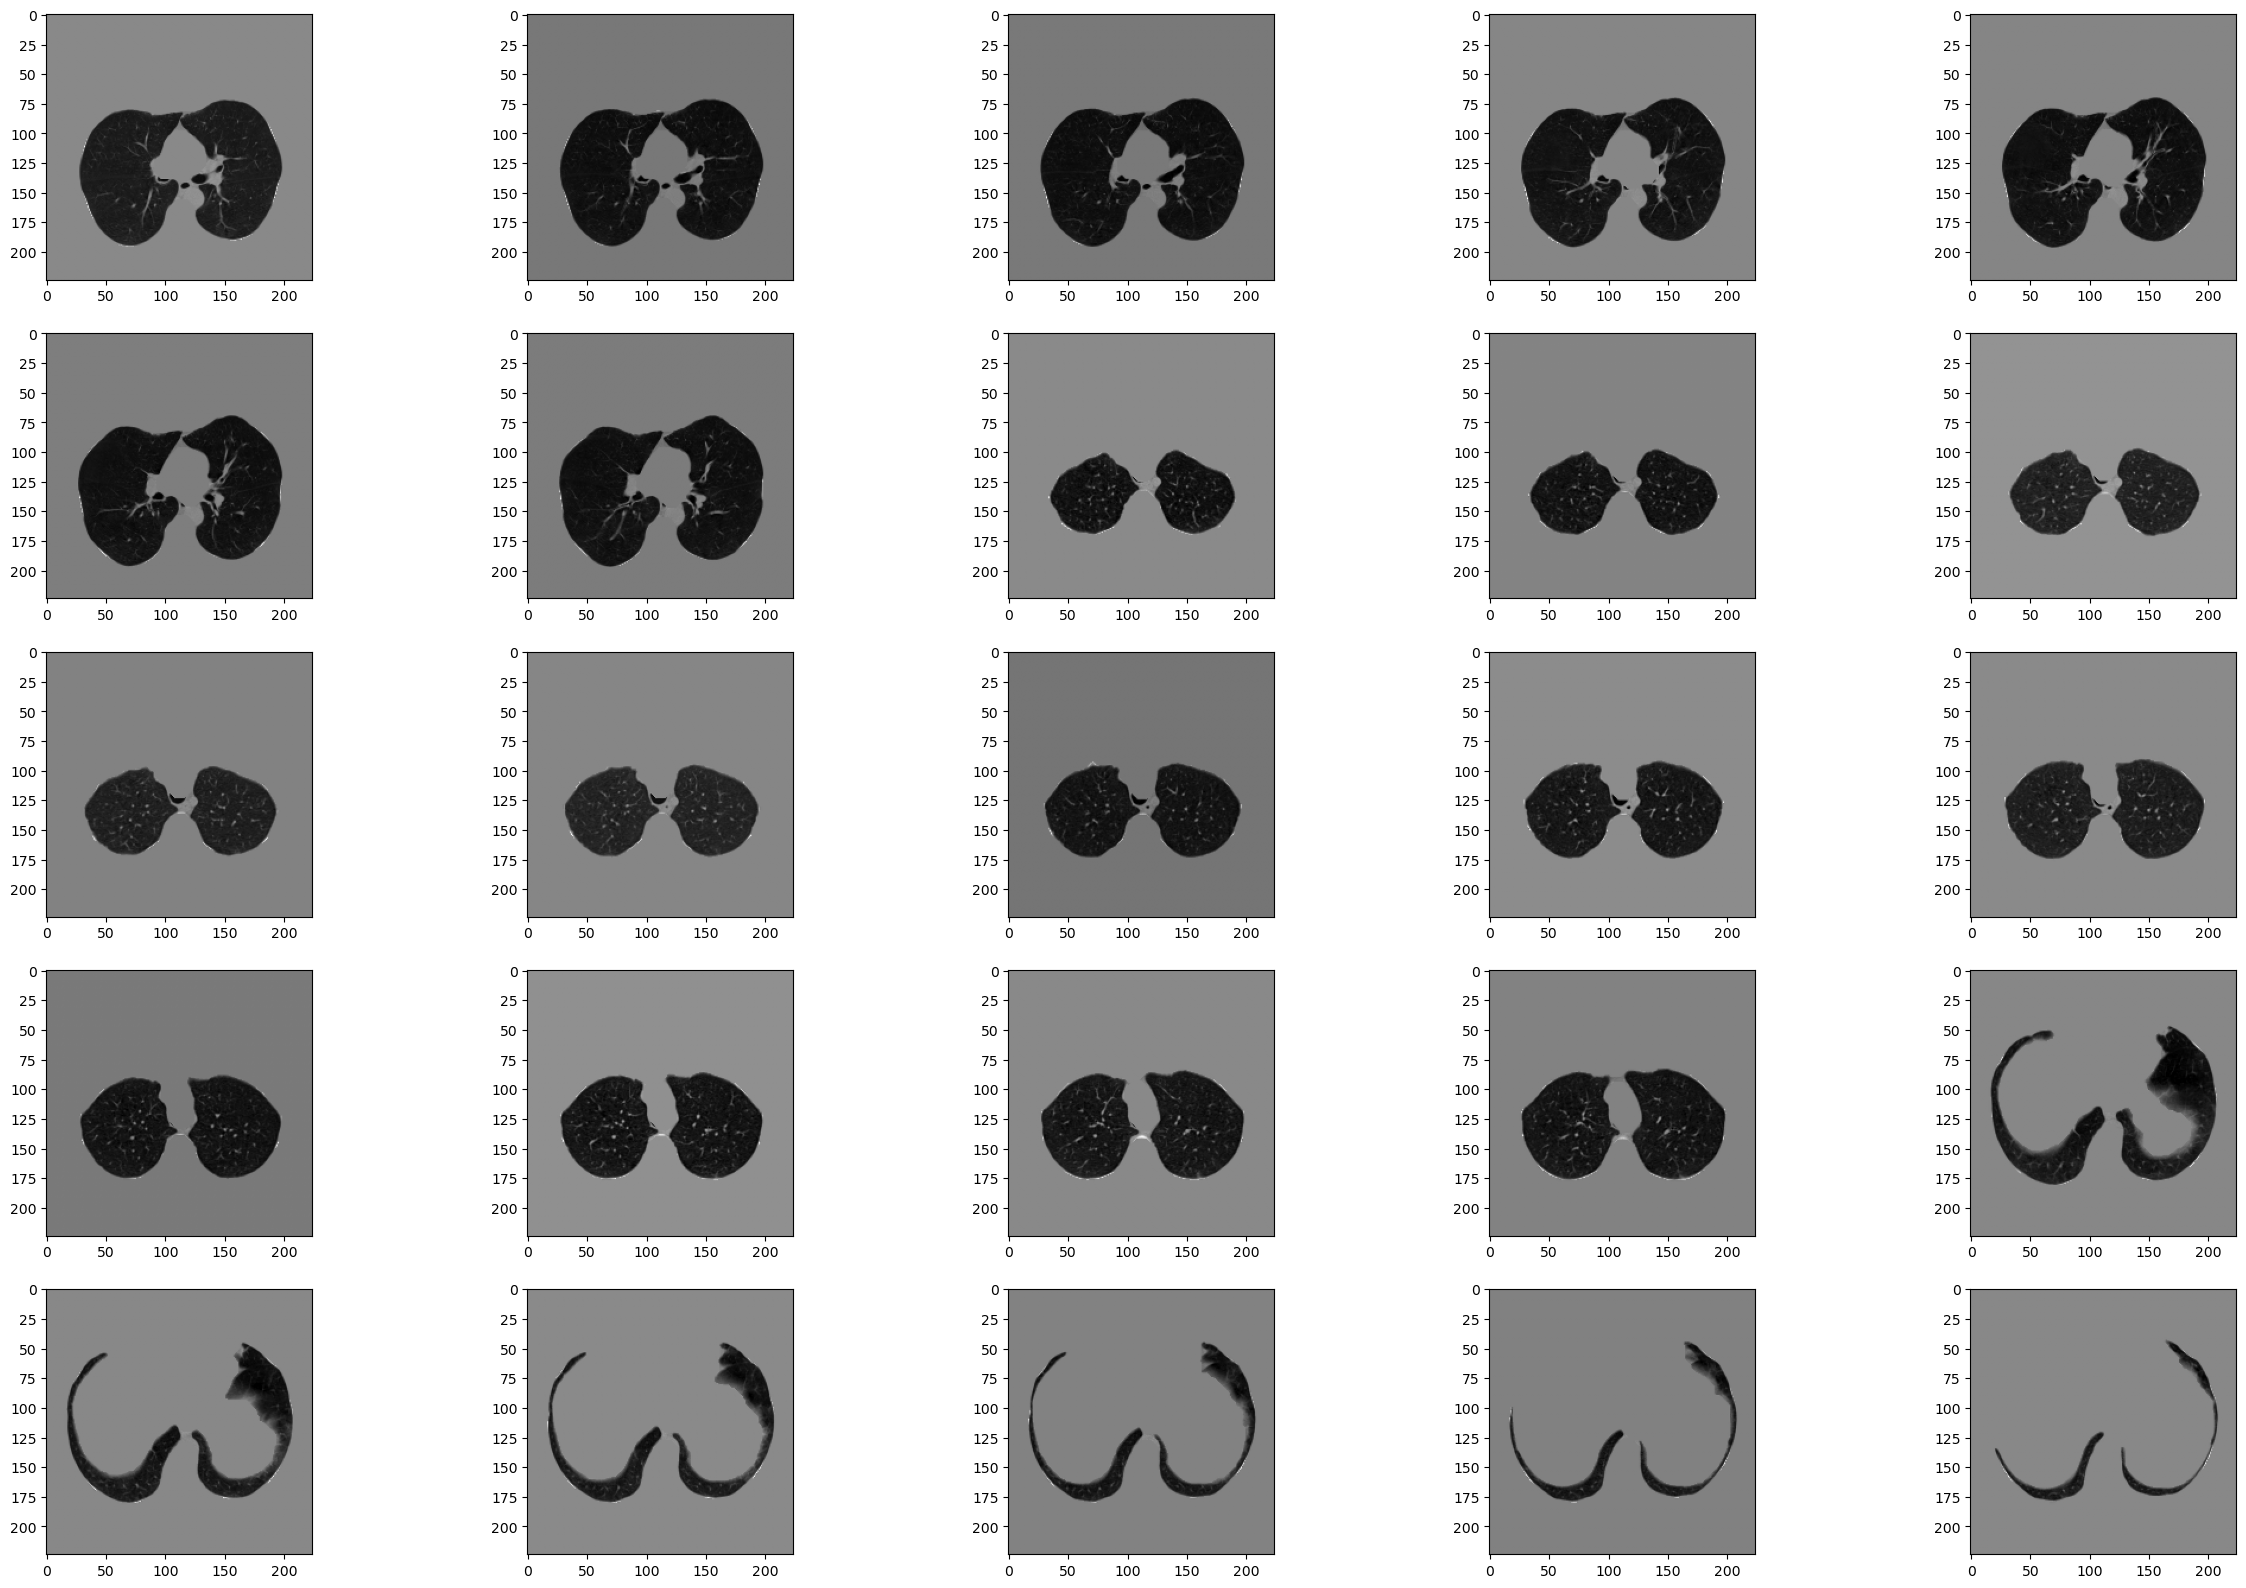

In [157]:
print_dicom_no_mask(picked_negative_data_slices_2D,5,5,5)

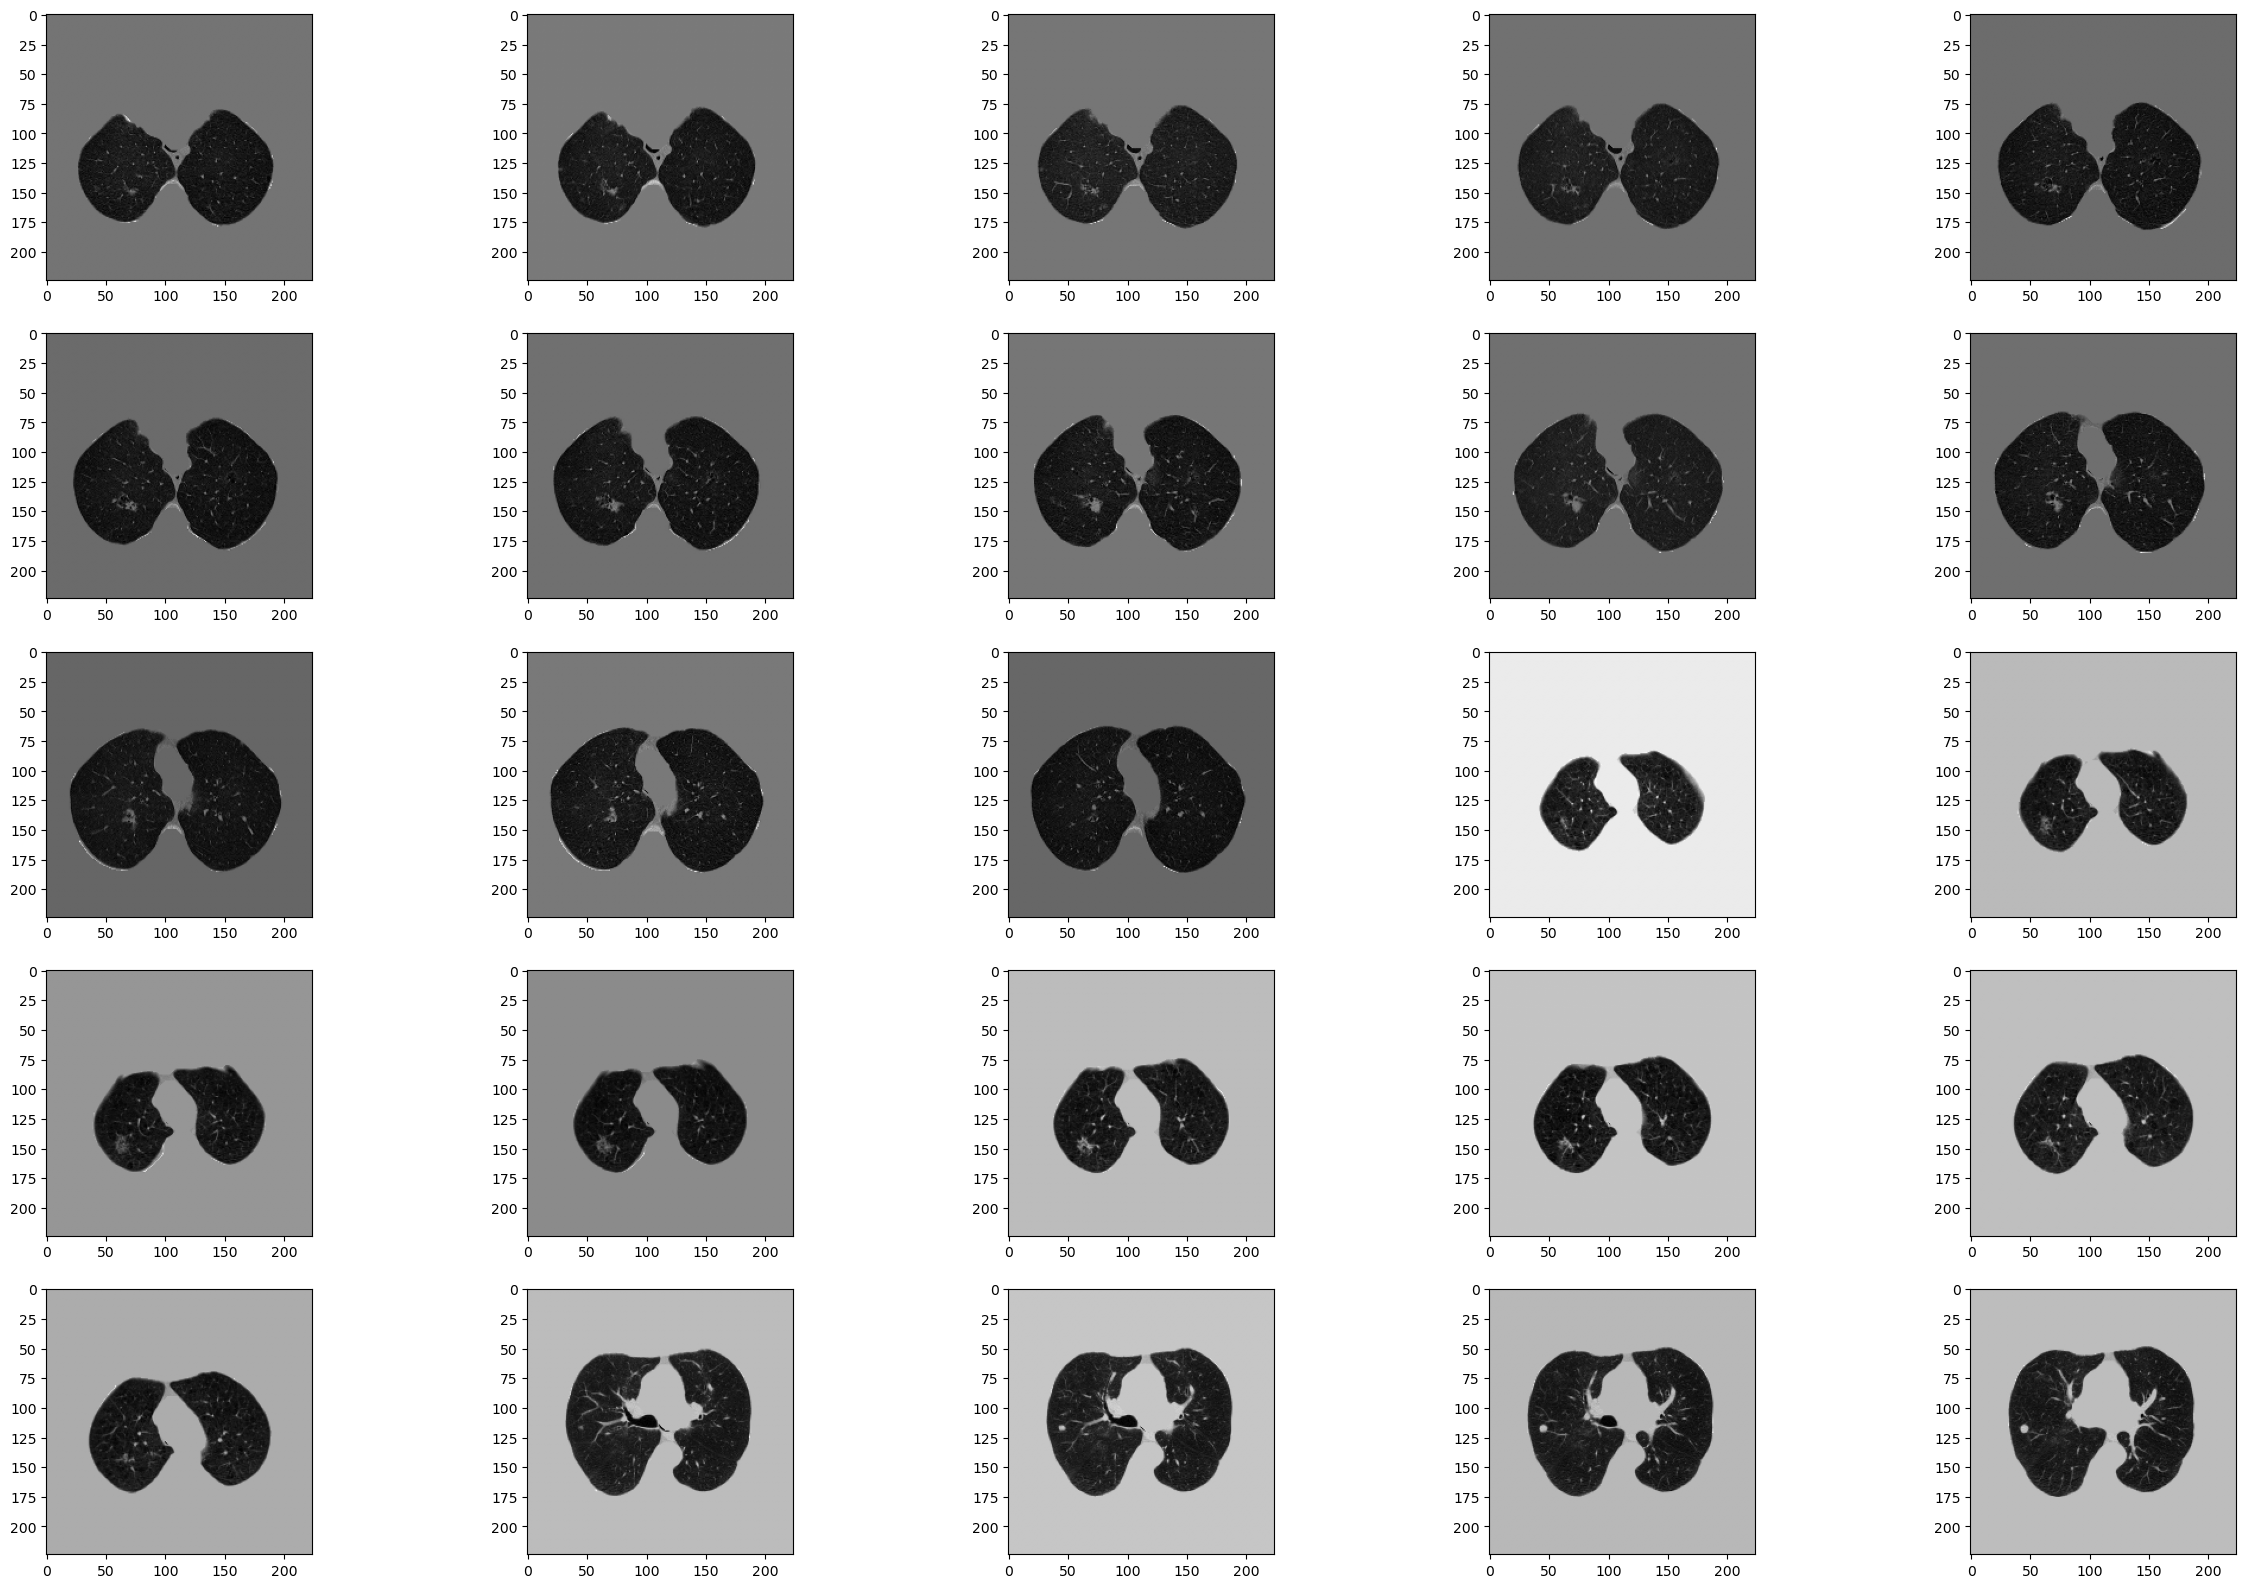

In [165]:
print_dicom_no_mask(Annotated_positive_list,5,5,0)

In [35]:
needed_neg_arr = 7140

In [36]:
Annotated_positive_list

array([[[ 1.71703352e-195, -4.01523680e-194, -1.46809709e-192, ...,
          9.63462017e-199,  4.32797625e-200,  0.00000000e+000],
        [-1.36561053e-193,  4.38727858e-178,  1.04060333e-176, ...,
         -7.86318187e-183, -3.31518922e-184,  0.00000000e+000],
        [-2.55106180e-192,  1.04060333e-176,  2.46817080e-175, ...,
         -1.86504073e-181, -7.86318187e-183,  0.00000000e+000],
        ...,
        [-3.85182262e-142,  6.97920737e-126,  1.65537389e-124, ...,
          7.35930050e-132,  3.10274824e-133,  0.00000000e+000],
        [-3.74579943e-143,  2.94249751e-127,  6.97920737e-126, ...,
          3.10274824e-133,  1.30814697e-134,  0.00000000e+000],
        [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000]],

       [[-5.74349501e-193,  3.41577673e-191,  7.66348079e-190, ...,
          1.43380579e-198,  5.38192383e-200,  0.00000000e+000],
        [ 2.41398537e-191, -1.65947686e-175, -3.93605539e-174

In [37]:
lung_cancer_type_arr = np.concatenate([Annotated_positive_list,picked_negative_data_slices_2D])

In [38]:
lung_cancer_type_pid_arr = np.concatenate([Annotated_positive_pid,picked_negative_data_slices_pid])

In [39]:
lung_cancer_type_pid_arr.__len__()

14279

In [45]:
lung_cancer_type_arr[:3]

array([[[ 1.71703352e-195, -4.01523680e-194, -1.46809709e-192, ...,
          9.63462017e-199,  4.32797625e-200,  0.00000000e+000],
        [-1.36561053e-193,  4.38727858e-178,  1.04060333e-176, ...,
         -7.86318187e-183, -3.31518922e-184,  0.00000000e+000],
        [-2.55106180e-192,  1.04060333e-176,  2.46817080e-175, ...,
         -1.86504073e-181, -7.86318187e-183,  0.00000000e+000],
        ...,
        [-3.85182262e-142,  6.97920737e-126,  1.65537389e-124, ...,
          7.35930050e-132,  3.10274824e-133,  0.00000000e+000],
        [-3.74579943e-143,  2.94249751e-127,  6.97920737e-126, ...,
          3.10274824e-133,  1.30814697e-134,  0.00000000e+000],
        [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000]],

       [[-5.74349501e-193,  3.41577673e-191,  7.66348079e-190, ...,
          1.43380579e-198,  5.38192383e-200,  0.00000000e+000],
        [ 2.41398537e-191, -1.65947686e-175, -3.93605539e-174

In [40]:
(len(lung_cancer_type_pid_arr),len(Annotated_positive_list),len(picked_negative_data_slices_2D))

(14279, 7139, 7140)

In [78]:
Positive_picked_slices =  7139
Negative_picked_slices =  7140
total = Positive_picked_slices + Negative_picked_slices
total

14279

In [46]:
Saveh5('final_preprocessed_datasets/lung_cancer_unprocessed',lung_cancer_type_pid_arr,lung_cancer_type_arr)

In [63]:
np.save('final_preprocessed_datasets/lung_cancer_combined_metadata.npy',np.concatenate([new_positive_slice_data,picked_negative_data]))

In [82]:
np.save('initial_preprocessing/lung_cancer_picked_negative_segmented_metadata.npy',picked_negative_data,allow_pickle=True)

In [77]:
(new_positive_slice_data.__len__(),picked_negative_data.__len__(),new_positive_slice_data.__len__() + picked_negative_data.__len__())

(597, 595, 1192)

In [80]:
total_metadata = np.load('final_preprocessed_datasets/lung_cancer_combined_metadata.npy',allow_pickle=True)
len(total_metadata)

1192

In [90]:
negative_picked_data = np.load('initial_preprocessing/lung_cancer_picked_negative_segmented_metadata.npy',allow_pickle=True)
negative_picked_data

array([{'pid': 102000, 'year_used': '1999', 'original_shape 3D': (164, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121], 'Errors': 'NA'},
       {'pid': 103567, 'year_used': '1999', 'original_shape 3D': (151, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96], 'Errors': 'NA'},
       {'pid': 102847, 'year_used': '2001', 'original_shape 3D': (142, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], 'Errors': 'Thickness greater than 2.5mm'},
       {'pid': 103712, 'year_used': '2000', 'original_shape 3D': (175, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], 'Errors': 'NA'},
       {'pid': 101571, 'year_used': '2001', 'original_shape 3D': (165, 512, 512), 'reshaped_to': (12, 224, 224), 'slices_used': [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52], 'Err

In [91]:
negative_picked_data.__len__()  

595

In [83]:
picked_negative_data_pid[-1]

NameError: name 'picked_negative_data_pid' is not defined

In [84]:
sorted(picked_negative_data_pid)

NameError: name 'picked_negative_data_pid' is not defined

In [94]:
picked_negative_data_slices_pid[-1]

103783

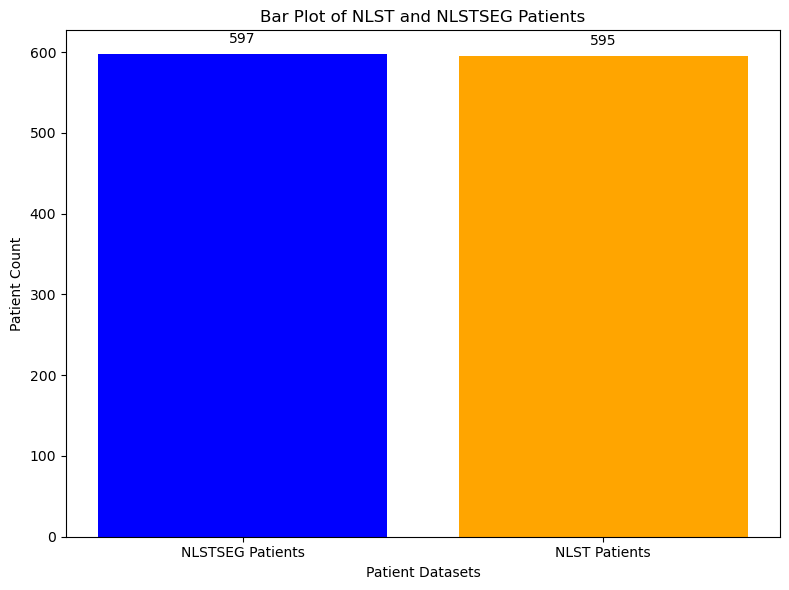

In [97]:
import matplotlib.pyplot as plt

# Data
categories = ['NLSTSEG Patients', 'NLST Patients']
lengths = [positive_slice_data.__len__(), negative_picked_data.__len__()]

# Bar plot
plt.figure(figsize=(8, 6))
plt.bar(categories, lengths, color=['blue', 'orange'])

# Adding labels and title
plt.xlabel('Patient Datasets')
plt.ylabel('Patient Count')
plt.title('Bar Plot of NLST and NLSTSEG Patients')

# Annotate bars with values
for i, length in enumerate(lengths):
    plt.text(i, length + 10, str(length), ha='center', va='bottom', fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()

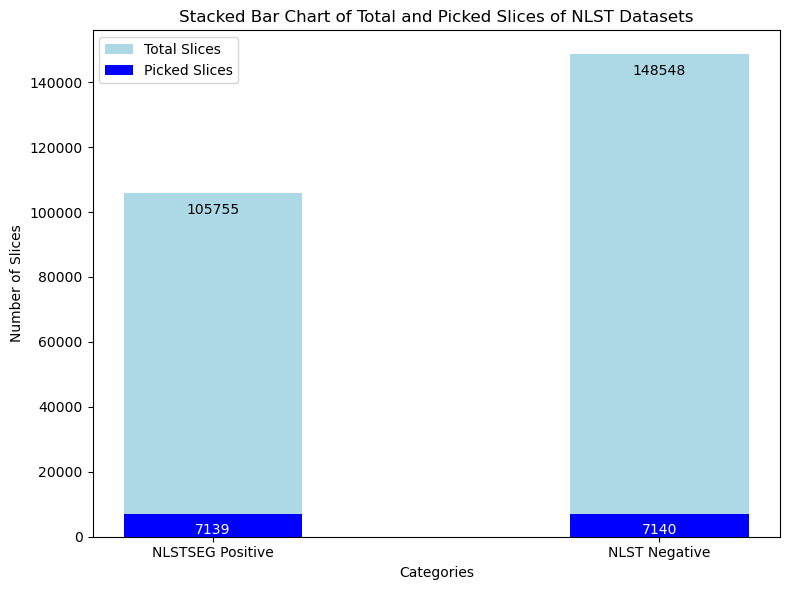

In [99]:
import numpy as np

import matplotlib.pyplot as plt

# Data
categories = ['NLSTSEG Positive', 'NLST Negative']
total_slices = [positive_total_slices, negative_total_slices]
picked_slices = [Positive_picked_slices, Negative_picked_slices]

# Bar width and positions
x = np.arange(len(categories))
width = 0.4

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
bars_total = ax.bar(x, total_slices, width, label='Total Slices', color='lightblue')
bars_picked = ax.bar(x, picked_slices, width, label='Picked Slices', color='blue')

# Adding labels and title
ax.set_xlabel('Categories')
ax.set_ylabel('Number of Slices')
ax.set_title('Stacked Bar Chart of Total and Picked Slices of NLST Datasets')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Annotate bars with values
for bar, total_value in zip(bars_total, total_slices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5000, f'{total_value}', 
            ha='center', va='center', color='black', fontsize=10)

for bar, picked_value in zip(bars_picked, picked_slices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5000, f'{picked_value}', 
            ha='center', va='center', color='white', fontsize=10)

# Display the chart
plt.tight_layout()
plt.show()

In [92]:
positive_slice_data.__len__()
negative_picked_data.__len__()  

595

# Data Transformation

In [100]:
import cv2
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [115]:
def CLAHE_implementation(img_arr):
    chale_arr = []
    for item in tqdm(img_arr,desc="Processing Image"):
        # image transformation
        item = cv2.normalize(
            item,
            None,
            alpha=0, 
            beta=255, 
            norm_type=cv2.NORM_MINMAX, 
            dtype=cv2.CV_16U)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

        # Apply CLAHE to the image
        clahe_img = clahe.apply(item)
        scaler = MinMaxScaler()
        clahe_img = scaler.fit_transform(clahe_img)
        clahe_img = clahe_img.astype(np.float32)
        chale_arr.append(clahe_img)

    return np.array(chale_arr)

In [101]:
negative_pid_chosen = [item['pid'] for item in negative_picked_data]

In [102]:
negative_pid_chosen.__len__()


595

In [103]:
sorted(negative_pid_chosen)

[100002,
 100010,
 100014,
 100020,
 100024,
 100030,
 100032,
 100037,
 100041,
 100043,
 100051,
 100067,
 100075,
 100089,
 100091,
 100093,
 100096,
 100099,
 100100,
 100102,
 100116,
 100137,
 100160,
 100164,
 100166,
 100173,
 100185,
 100187,
 100200,
 100209,
 100212,
 100215,
 100221,
 100225,
 100226,
 100231,
 100239,
 100243,
 100247,
 100253,
 100256,
 100258,
 100260,
 100272,
 100273,
 100275,
 100277,
 100290,
 100304,
 100319,
 100320,
 100328,
 100329,
 100331,
 100342,
 100347,
 100351,
 100352,
 100357,
 100362,
 100364,
 100371,
 100374,
 100375,
 100389,
 100400,
 100401,
 100409,
 100413,
 100420,
 100442,
 100443,
 100451,
 100456,
 100461,
 100462,
 100470,
 100476,
 100480,
 100487,
 100494,
 100501,
 100506,
 100524,
 100528,
 100534,
 100537,
 100540,
 100543,
 100551,
 100553,
 100555,
 100559,
 100573,
 100583,
 100602,
 100605,
 100616,
 100631,
 100640,
 100661,
 100662,
 100668,
 100677,
 100682,
 100686,
 100692,
 100702,
 100710,
 100712,
 100717,
 

In [104]:
Negative_data

,pid,race,cigsmok,gender,age,Stage_AJCC7th
0,100002,1,1,1,66,No Lung Cancer
1,100006,1,1,2,56,No Lung Cancer
2,100008,1,1,2,56,No Lung Cancer
3,100009,1,1,1,55,No Lung Cancer
4,100010,1,0,1,68,No Lung Cancer
...,...,...,...,...,...,...
32933,218888,1,1,2,58,No Lung Cancer
32934,218889,1,1,2,64,No Lung Cancer
32935,218890,1,1,2,73,No Lung Cancer
32936,218893,1,0,1,69,No Lung Cancer


In [105]:
Negative_df = Negative_data[Negative_data['pid'].isin(pid_chosen)]

In [106]:
Positive_df = Positive_data[['ID', 'race', 'cigsmok', 'gender', 'age','Stage AJCC7th']]

In [107]:
Negative_df

,pid,race,cigsmok,gender,age,Stage_AJCC7th
0,100002,1,1,1,66,No Lung Cancer
1,100006,1,1,2,56,No Lung Cancer
2,100008,1,1,2,56,No Lung Cancer
3,100009,1,1,1,55,No Lung Cancer
4,100010,1,0,1,68,No Lung Cancer
...,...,...,...,...,...,...
32933,218888,1,1,2,58,No Lung Cancer
32934,218889,1,1,2,64,No Lung Cancer
32935,218890,1,1,2,73,No Lung Cancer
32936,218893,1,0,1,69,No Lung Cancer


In [108]:
Positive_df

,ID,race,cigsmok,gender,age,Stage AJCC7th
0,100012,1,1,2,61,Stage IA
1,100147,1,0,1,68,Stage IA
2,100158,1,0,1,65,Stage IA
3,100242,1,0,2,60,Stage IA
4,100280,1,1,2,60,Stage IA
...,...,...,...,...,...,...
592,218307,1,1,2,72,Stage IIIA
593,218357,2,1,1,66,Stage IV
594,218368,1,0,2,74,Stage IV
595,218391,1,0,1,66,Stage IA


In [109]:
Negative_df.columns = list(Positive_df.columns)
Negative_df = Negative_df.reset_index(drop=True)
Negative_df.head()

,ID,race,cigsmok,gender,age,Stage AJCC7th
0,100002,1,1,1,66,No Lung Cancer
1,100006,1,1,2,56,No Lung Cancer
2,100008,1,1,2,56,No Lung Cancer
3,100009,1,1,1,55,No Lung Cancer
4,100010,1,0,1,68,No Lung Cancer


In [110]:
Negative_df.__len__()

32938

In [111]:
Lung_Cancer_EHR = pd.concat([Positive_df,Negative_df]).reset_index(drop=True)

In [112]:
Positive_df.iloc[:,1:].describe()

,race,cigsmok,gender,age
count,597.000000,597.000000,597.00000,597.000000
mean,1.303183,0.559464,1.41876,63.886097
std,4.050877,0.496868,0.49377,5.293445
min,1.000000,0.000000,1.00000,55.000000
25%,1.000000,0.000000,1.00000,59.000000
50%,1.000000,1.000000,1.00000,64.000000
75%,1.000000,1.000000,2.00000,68.000000
max,99.000000,1.000000,2.00000,74.000000


In [113]:
Negative_df.iloc[:,1:].describe()

,race,cigsmok,gender,age
count,32938.000000,32938.000000,32938.000000,32938.000000
mean,1.568614,0.456767,1.407311,61.149432
std,6.266790,0.498135,0.491341,4.913672
min,1.000000,0.000000,1.000000,52.000000
25%,1.000000,0.000000,1.000000,57.000000
50%,1.000000,0.000000,1.000000,60.000000
75%,1.000000,1.000000,2.000000,64.000000
max,99.000000,1.000000,2.000000,79.000000


In [18]:
Lung_Cancer_EHR.to_csv("Lung_Cancer_EHR.csv",index=False)

NameError: name 'Lung_Cancer_EHR' is not defined

In [114]:
(lung_cancer_type_arr[0].max(),lung_cancer_type_arr[0].min())

NameError: name 'lung_cancer_type_arr' is not defined

In [20]:
clahe_arr = CLAHE_implementation(lung_cancer_type_arr)

NameError: name 'lung_cancer_type_arr' is not defined

In [21]:
Saveh5('final_preprocessed_datasets/lung_cancer_detection_segmented',clahe_arr,lung_cancer_type_pid_arr)

NameError: name 'Saveh5' is not defined

In [128]:
lung_cancer_type_arr,lung_cancer_type_pid_arr = Loadh5(directory='final_preprocessed_datasets/lung_cancer_detection_segmented.h5')
Lung_Cancer_EHR = pd.read_csv("Lung_Cancer_EHR.csv")

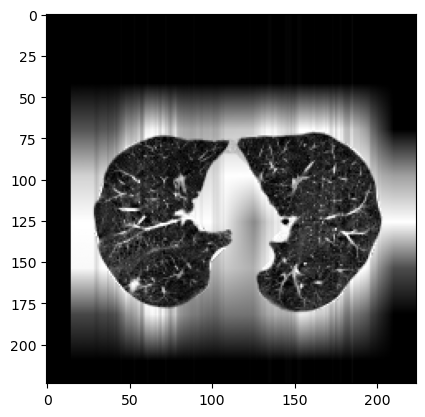

In [133]:
plt.imshow(lung_cancer_type_arr[5005],cmap='grey')

In [25]:
# REMEMBER THIS MAP
# this do not work
lung_cancer_map = {'No Lung Cancer': 0,'Stage IV':1,'Stage IA':2, 'Stage IB':3, 'Stage IIA':4, 'Stage IIIA':5,'Stage IIIB':6, 'Stage IIB':7}
lung_cancer_map

{'No Lung Cancer': 0,
 'Stage IV': 1,
 'Stage IA': 2,
 'Stage IB': 3,
 'Stage IIA': 4,
 'Stage IIIA': 5,
 'Stage IIIB': 6,
 'Stage IIB': 7}

In [116]:
lung_cancer_map2 = {'No Lung Cancer': 0,'Stage IV':1,'Stage IA':1, 'Stage IB':1, 'Stage IIA':1, 'Stage IIIA':1,'Stage IIIB':1, 'Stage IIB':1}
lung_cancer_map2

{'No Lung Cancer': 0,
 'Stage IV': 1,
 'Stage IA': 1,
 'Stage IB': 1,
 'Stage IIA': 1,
 'Stage IIIA': 1,
 'Stage IIIB': 1,
 'Stage IIB': 1}

In [129]:
def NLST_ItemGenerator(array_pids,array_images,lungcancer_df,dict_labels={'No Lung Cancer': 0,'Stage IV':1,'Stage IA':2, 'Stage IB':1, 'Stage IIA':1, 'Stage IIIA':1,'Stage IIIB':1, 'Stage IIB':1}):
    dict_list = []
    dict_label_list = dict_labels
    for index,dict_items in enumerate(array_pids):
        dataframe = lungcancer_df[lungcancer_df['ID']==dict_items]
        table_item = dataframe[['race','cigsmok','gender','age']].to_numpy()[0]
        label_item = dict_label_list[dataframe['Stage AJCC7th'].to_numpy()[0]]
        dict_list.append({'pid': dict_items, 'image':array_images[index],'table':table_item,'label':label_item})
    return dict_list


In [130]:
lung_cancer_dict_values = NLST_ItemGenerator(lung_cancer_type_pid_arr,lung_cancer_type_arr,Lung_Cancer_EHR,dict_labels=lung_cancer_map2)

In [131]:
lung_cancer_labels = []
for index in range(len(lung_cancer_dict_values)):
    lung_cancer_labels.append(lung_cancer_dict_values[index]['label'])

In [132]:
item_array = []
for index,item in enumerate(lung_cancer_dict_values):
    if item['pid'] == 108611:
        print(index,item)
        item_array.append(item['image'])

863 {'pid': 108611, 'image': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'table': array([ 1,  1,  1, 73], dtype=int64), 'label': 1}
864 {'pid': 108611, 'image': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'table': array([ 1,  1,  1, 73], dtype=int64), 'label': 1}
865 {'pid': 108611, 'image': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'table': array([ 1,  1, 

PID 108611 info: 
        ID  race  cigsmok  gender  age Stage AJCC7th
93  108611     1        1       1   73      Stage IA


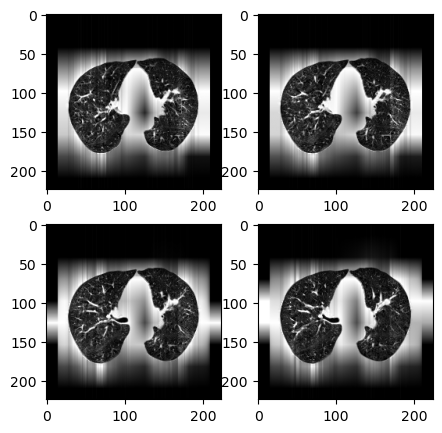

In [140]:
print_dicom_no_mask_with_det(item_array,Lung_Cancer_EHR,108611,2,2,0,nii_format=False,figsize=(5,5))

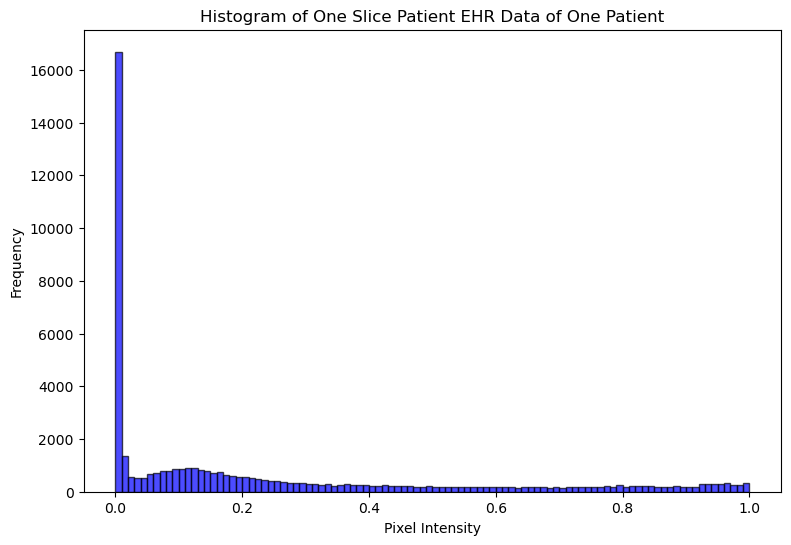

In [148]:
slice_index = 0 # Replace with the desired slice index
selected_slice = item_array[slice_index]

# Plot the histogram
plt.figure(figsize=(9, 6))
plt.hist(selected_slice.ravel(), bins=100, color='blue', alpha=0.7, edgecolor='black')
plt.title(f'Histogram of One Slice Patient EHR Data of One Patient')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [217]:
Lung_Cancer_EHR[Lung_Cancer_EHR["ID"].isin(set(lung_cancer_type_pid_arr))].to_csv("Lung_Cancer_multimodal_patient_EHR.csv",index=False)

In [218]:
Lung_Cancer_EHR[~(Lung_Cancer_EHR["ID"].isin(set(lung_cancer_type_pid_arr)))].to_csv("Lung_Cancer_training_EHR.csv",index=False)

In [220]:
np.save('final_preprocessed_datasets/lung_cancer_detection_labels.npy',lung_cancer_labels)

In [223]:
np.save('final_preprocessed_datasets/lung_cancer_detection_pid.npy',lung_cancer_type_pid_arr)

In [134]:
Patient_EHR = pd.read_csv("Lung_Cancer_multimodal_patient_EHR.csv")
Patient_EHR.head()

,ID,race,cigsmok,gender,age,Stage AJCC7th
0,100012,1,1,2,61,Stage IA
1,100147,1,0,1,68,Stage IA
2,100158,1,0,1,65,Stage IA
3,100242,1,0,2,60,Stage IA
4,100280,1,1,2,60,Stage IA


In [143]:
Lung_canc = [0 if item == 'No Lung Cancer' else 1 for item in Patient_EHR['Stage AJCC7th'].tolist()]
Patient_EHR_new_data_corr = Patient_EHR.copy()
Patient_EHR_new_data_corr['Lung_Cancer'] = Lung_canc
Patient_EHR_new_data_corr = Patient_EHR_new_data_corr[['race', 'cigsmok', 'gender', 'age','Lung_Cancer']]

In [144]:
Patient_EHR_new_data_corr

,race,cigsmok,gender,age,Lung_Cancer
0,1,1,2,61,1
1,1,0,1,68,1
2,1,0,1,65,1
3,1,0,2,60,1
4,1,1,2,60,1
...,...,...,...,...,...
1187,1,0,1,61,0
1188,1,0,2,56,0
1189,1,1,1,63,0
1190,1,0,1,58,0


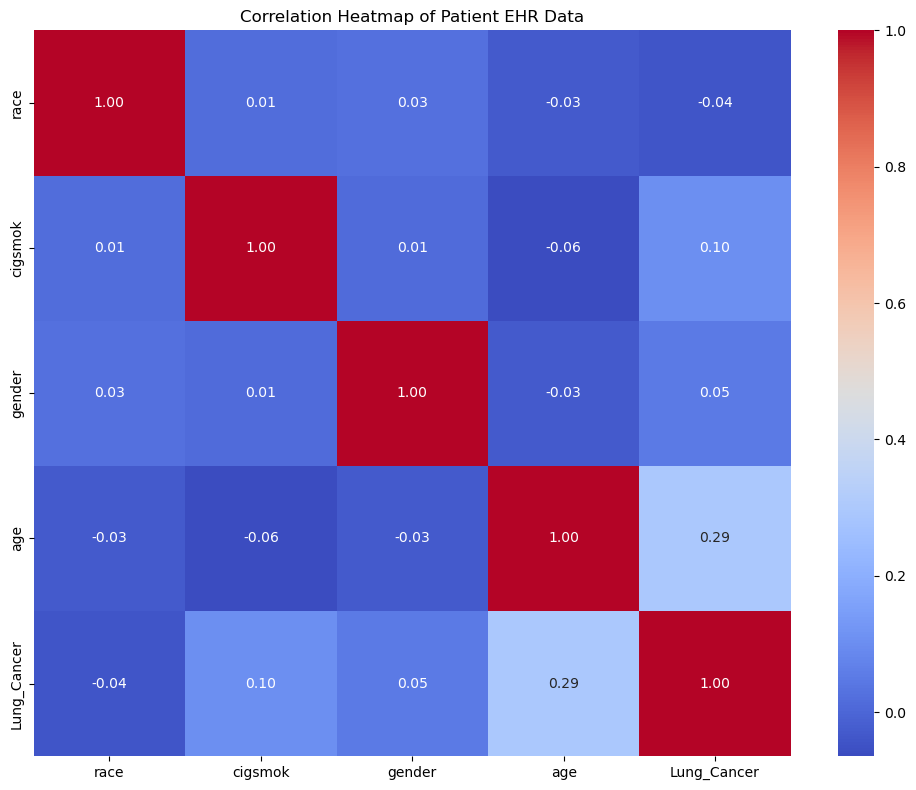

In [145]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = Patient_EHR_new_data_corr.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Add title
plt.title("Correlation Heatmap of Patient EHR Data")

# Display the heatmap
plt.tight_layout()
plt.show()

In [ ]:
Patient_EHR_data_corr = Patient_EHR[Patient_EHR['Stage AJCC7th'] != 'No Lung Cancer']

In [138]:
Patient_EHR.describe()

,ID,race,cigsmok,gender,age
count,1192.000000,1192.000000,1192.000000,1192.000000,1192.000000
mean,127049.541946,1.570470,0.508389,1.394295,62.339765
std,41023.317727,6.361228,0.500139,0.488904,5.266962
min,100002.000000,1.000000,0.000000,1.000000,55.000000
25%,101701.500000,1.000000,0.000000,1.000000,58.000000
50%,103551.500000,1.000000,1.000000,1.000000,62.000000
75%,127898.250000,1.000000,1.000000,2.000000,66.000000
max,218510.000000,99.000000,1.000000,2.000000,74.000000


In [139]:
race_counts = Patient_EHR.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Patient_EHR)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


Distribution of patients by race:


,race,# count,percentage
0,1,1094,91.7785%
1,2,46,3.8591%
2,3,25,2.0973%
3,4,5,0.4195%
4,5,6,0.5034%
5,6,11,0.9228%
6,99,5,0.4195%


In [140]:
gender_counts = Patient_EHR.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Patient_EHR)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

Distribution of patients by race:


,gender,# count,percentage
0,1,722,60.5705%
1,2,470,39.4295%


In [141]:
smoke_count = Patient_EHR.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Patient_EHR)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

Distribution of patients by race:


,cigsmok,# count,percentage
0,0,586,49.1611%
1,1,606,50.8389%


In [142]:
Non_Patient_EHR = pd.read_csv("Lung_Cancer_training_EHR.csv")
Non_Patient_EHR.head()

,ID,race,cigsmok,gender,age,Stage AJCC7th
0,100006,1,1,2,56,No Lung Cancer
1,100008,1,1,2,56,No Lung Cancer
2,100009,1,1,1,55,No Lung Cancer
3,100015,1,1,1,59,No Lung Cancer
4,100017,1,1,2,57,No Lung Cancer


In [143]:
Non_Patient_EHR.describe()

,ID,race,cigsmok,gender,age
count,32343.000000,32343.000000,32343.000000,32343.000000,32343.000000
mean,150944.531985,1.563646,0.456760,1.408002,61.156077
std,44791.196454,6.229662,0.498135,0.491471,4.916211
min,100006.000000,1.000000,0.000000,1.000000,52.000000
25%,114301.000000,1.000000,0.000000,1.000000,57.000000
50%,127499.000000,1.000000,0.000000,1.000000,60.000000
75%,205792.000000,1.000000,1.000000,2.000000,64.000000
max,218894.000000,99.000000,1.000000,2.000000,79.000000


In [144]:
race_counts = Non_Patient_EHR.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Non_Patient_EHR)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


Distribution of patients by race:


,race,# count,percentage
0,1,29572,91.4325%
1,2,1331,4.1153%
2,3,687,2.1241%
3,4,111,0.3432%
4,5,108,0.3339%
5,6,404,1.2491%
6,99,130,0.4019%


In [145]:
gender_counts = Non_Patient_EHR.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Non_Patient_EHR)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

Distribution of patients by race:


,gender,# count,percentage
0,1,19147,59.1998%
1,2,13196,40.8002%


In [146]:
smoke_count = Non_Patient_EHR.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Non_Patient_EHR)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.4f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

Distribution of patients by race:


,cigsmok,# count,percentage
0,0,17570,54.3240%
1,1,14773,45.6760%


In [147]:
# Add a category column to each DataFrame
race_counts['category'] = 'race'
gender_counts['category'] = 'gender'
smoke_count['category'] = 'cigsmok'

# Rename the first column to 'value' for consistency
race_counts.rename(columns={'race': 'value'}, inplace=True)
gender_counts.rename(columns={'gender': 'value'}, inplace=True)
smoke_count.rename(columns={'cigsmok': 'value'}, inplace=True)

# Combine the DataFrames
combined_stats = pd.concat([race_counts, gender_counts, smoke_count], ignore_index=True)

# Display the combined dataset
combined_stats.to_csv("Non_Patient_EHR_Statistics.csv",index=False)
combined_stats

,value,# count,percentage,category
0,1,29572,91.4325%,race
1,2,1331,4.1153%,race
2,3,687,2.1241%,race
3,4,111,0.3432%,race
4,5,108,0.3339%,race
5,6,404,1.2491%,race
6,99,130,0.4019%,race
7,1,19147,59.1998%,gender
8,2,13196,40.8002%,gender
9,0,17570,54.3240%,cigsmok


In [148]:
Patient_EHR_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
Patient_EHR_encoder_age = MinMaxScaler()

In [149]:
Patient_EHR['ID'].to_numpy().reshape(-1,1)

array([[100012],
       [100147],
       [100158],
       ...,
       [103771],
       [103781],
       [103783]], dtype=int64)

In [150]:
Patient_EHR_encoded_array = Patient_EHR_encoder.fit_transform(Patient_EHR[['race','cigsmok','gender']])

# 4. Get feature names and create a DataFrame
feature_names = Patient_EHR_encoder.get_feature_names_out(['race','cigsmok','gender'])
Patient_EHR_encoded_array_age = Patient_EHR_encoder_age.fit_transform(Patient_EHR[['age']])
Combined_features = ['ID'] + feature_names.tolist() + ['age']  + ['Stage AJCC7th']
Combined_Patient_EHR = np.concatenate([Patient_EHR['ID'].to_numpy().reshape(-1,1),Patient_EHR_encoded_array,Patient_EHR_encoded_array_age,
    Patient_EHR['Stage AJCC7th'].to_numpy().reshape(-1,1)],axis=1)
Patient_EHR_cat = pd.DataFrame(Combined_Patient_EHR, columns=Combined_features)
Patient_EHR_cat['ID'] = Patient_EHR_cat['ID'].astype(int)

In [151]:
Patient_EHR_cat

,ID,race_1,race_2,race_3,race_4,race_5,race_6,race_99,cigsmok_0,cigsmok_1,gender_1,gender_2,age,Stage AJCC7th
0,100012,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.315789,Stage IA
1,100147,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.684211,Stage IA
2,100158,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.526316,Stage IA
3,100242,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.263158,Stage IA
4,100280,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.263158,Stage IA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187,103755,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.315789,No Lung Cancer
1188,103761,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.052632,No Lung Cancer
1189,103771,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.421053,No Lung Cancer
1190,103781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.157895,No Lung Cancer


In [152]:
Patient_EHR['Stage AJCC7th'].value_counts(normalize=True)

Stage AJCC7th
No Lung Cancer    0.499161
Stage IA          0.264262
Stage IIIA        0.061242
Stage IV          0.058725
Stage IB          0.052852
Stage IIA         0.036074
Stage IIB         0.015101
Stage IIIB        0.012584
Name: proportion, dtype: float64

In [153]:
Patient_EHR_cat.describe()

,ID
count,1192.000000
mean,127049.541946
std,41023.317727
min,100002.000000
25%,101701.500000
50%,103551.500000
75%,127898.250000
max,218510.000000


In [154]:
NonPatient_EHR_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
NonPatient_EHR_encoder_age = MinMaxScaler()

In [155]:
NonPatient_EHR_encoded_array = NonPatient_EHR_encoder.fit_transform(Non_Patient_EHR[['race','cigsmok','gender']])

# 4. Get feature names and create a DataFrame
feature_names = NonPatient_EHR_encoder.get_feature_names_out(['race','cigsmok','gender'])
NonPatient_EHR_encoded_array_age = NonPatient_EHR_encoder_age.fit_transform(Non_Patient_EHR[['age']])
NonPatientCombined_features = ['ID'] + feature_names.tolist() + ['age'] + ['Stage AJCC7th']
NonCombined_Patient_EHR = np.concatenate([Non_Patient_EHR['ID'].to_numpy().reshape(-1,1),NonPatient_EHR_encoded_array,NonPatient_EHR_encoded_array_age,
    Non_Patient_EHR['Stage AJCC7th'].to_numpy().reshape(-1,1)],axis=1)
NonPatient_EHR_cat = pd.DataFrame(NonCombined_Patient_EHR, columns=NonPatientCombined_features)
NonPatient_EHR_cat['ID'] = NonPatient_EHR_cat['ID'].astype(int)

In [156]:
NonPatient_EHR_cat

,ID,race_1,race_2,race_3,race_4,race_5,race_6,race_99,cigsmok_0,cigsmok_1,gender_1,gender_2,age,Stage AJCC7th
0,100006,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.148148,No Lung Cancer
1,100008,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.148148,No Lung Cancer
2,100009,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.111111,No Lung Cancer
3,100015,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.259259,No Lung Cancer
4,100017,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.185185,No Lung Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32338,218888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.222222,No Lung Cancer
32339,218889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.444444,No Lung Cancer
32340,218890,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.777778,No Lung Cancer
32341,218893,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.62963,No Lung Cancer


In [157]:
0.518519 *(79-52) + 52

66.000013

In [158]:
Non_Patient_EHR.iloc[:,1:-2]

,race,cigsmok,gender
0,1,1,2
1,1,1,2
2,1,1,1
3,1,1,1
4,1,1,2
...,...,...,...
32338,1,1,2
32339,1,1,2
32340,1,1,2
32341,1,0,1


In [159]:
race_class = np.unique(Non_Patient_EHR['race'])
cigsmok_class = np.unique(Non_Patient_EHR['cigsmok'])
gender_class = np.unique(Non_Patient_EHR['gender'])
race_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=race_class,
    y=Non_Patient_EHR['race']
)
cigsmok_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=cigsmok_class,
    y=Non_Patient_EHR['cigsmok']
)
gender_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=gender_class,
    y=Non_Patient_EHR['gender']
)

class_weights = np.concatenate([race_class_weights,cigsmok_class_weights,gender_class_weights])

In [160]:
class_weight_map = np.tile(class_weights,(len(Non_Patient_EHR),1))

In [161]:
class_weight_map.shape

(32343, 11)

In [162]:
np.save("final_preprocessed_datasets/class_weights.npy",class_weight_map)

In [49]:
Patient_EHR_cat.to_csv("Lung_Cancer_multimodal_patient_EHR_categorical.csv",index=False)
NonPatient_EHR_cat.to_csv("Lung_Cancer_training_EHR_categorical.csv",index=False)  

In [163]:
Patient_EHR = pd.read_csv("Lung_Cancer_multimodal_patient_EHR_categorical.csv")
Non_Patient_EHR = pd.read_csv("Lung_Cancer_training_EHR_categorical.csv")

In [164]:
Non_Patient_EHR.__len__()

32343

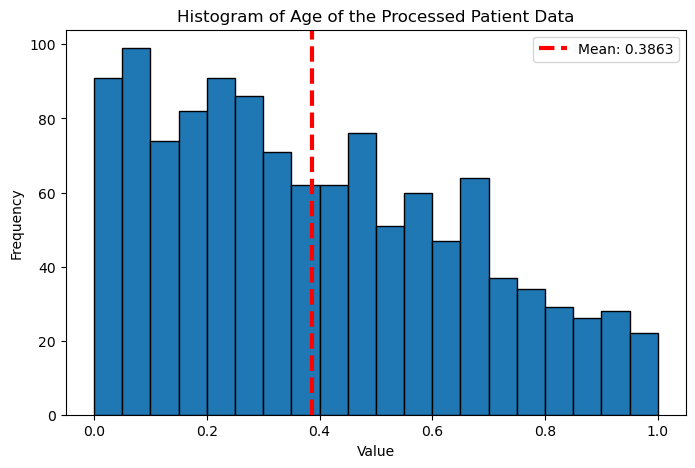

In [165]:
plt.figure(figsize=(8, 5))
plt.hist(Patient_EHR['age'], bins=20, edgecolor='black')

plt.title('Histogram of Age of the Processed Patient Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.axvline(
    Patient_EHR['age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=3,
    label=f'Mean: {Patient_EHR['age'].mean():.4f}'
)
plt.legend()
plt.show()

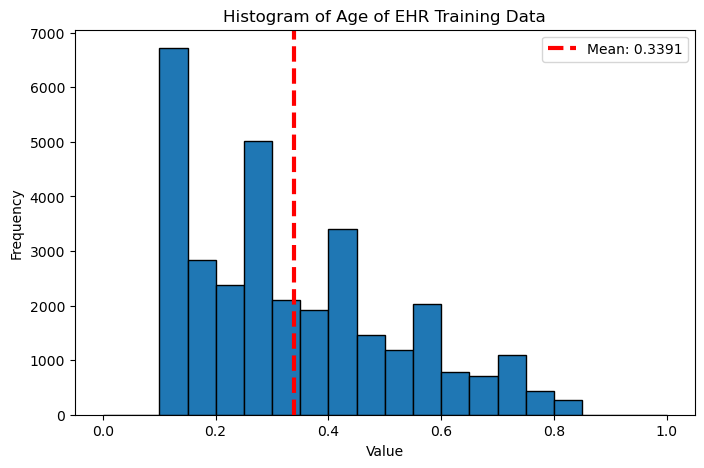

In [166]:
plt.figure(figsize=(8, 5))
plt.hist(Non_Patient_EHR['age'], bins=20, edgecolor='black')

plt.title('Histogram of Age of EHR Training Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.axvline(
    Non_Patient_EHR['age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=3,
    label=f'Mean: {Non_Patient_EHR['age'].mean():.4f}'
)
plt.legend()
plt.show()